# Mapa de Calor — Movilidad hacia UPCT 
**Estudio de movilidad MITMA · Región de Murcia**

**Años cubiertos:** 2022 · 2023 · 2024 · 2025  
Si falta algún parquet, el notebook avisa y omite ese año sin romperse.  
Para generarlo: ejecuta `codigo_filtrado_v2.py` con `AÑO = <año deseado>`.

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN: ZONAS DEL ESTUDIO
# ─────────────────────────────────────────────────────────────────────────────

# Lista ordenada de las 15 zonas. El índice en esta lista define el número
# que aparece en los círculos del mapa (siempre el mismo número para la misma zona).
ZONAS_ESTUDIO = [
    '3003001', '3003002', '3003003', '3003004',
    '3003005', '3003006', '3003007', '3003008',
    '30027',   '30005',   '30035',   '30036',
    '3003701', '3003702', '30902'
]

# Diccionario: zona_id → número de índice (1-15)
INDICE_ZONAS = {zona: i for i, zona in enumerate(ZONAS_ESTUDIO, 1)}

# Nombres completos para la tabla índice
NOMBRES_TABLA = {
    '3003001': 'Murcia D1 (San Antón / San Andrés)',
    '3003002': 'Murcia D2 (La Flota / La Fama)',
    '3003003': 'Murcia D3 (El Carmen / Infante)',
    '3003004': 'Murcia D4 (Churra / Cabezo de Torres)',
    '3003005': 'Murcia D5 (El Palmar / La Alberca)',
    '3003006': 'Murcia D6 (Beniaján / Los Dolores)',
    '3003007': 'Murcia D7 (La Ñora / Guadalupe)',
    '3003008': 'Murcia D8 (Corvera / Sucina)',
    '30027': 'Molina de Segura',
    '30005': 'Alcantarilla',
    '30035': 'San Javier',
    '30036': 'San Pedro del Pinatar',
    '3003701': 'Torre-Pacheco D1 (Centro)',
    '3003702': 'Torre-Pacheco D2 (Roldán / Balsicas)',
    '30902': 'Los Alcázares'
}

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CARGA DE DATOS — todos los años disponibles
# Los parquets ya están pre-filtrados a la franja 0-25 años,
# por lo que no existe columna 'edad'. Se cargan directamente.
# ─────────────────────────────────────────────────────────────────────────────

def cargar_datos_año(año):
    ruta = f'..//data//viajes_murcia_cartagena_{año}.parquet'
    if not os.path.exists(ruta):
        return None

    df = pd.read_parquet(ruta)

    # 1. Limpieza estricta de orígenes
    df['origen'] = df['origen'].astype(str).str.strip()
    
    # 2. Limpieza estricta de viajes (salvando las comas)
    df['viajes'] = pd.to_numeric(df['viajes'].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)
    
    return df.groupby('origen')['viajes'].sum().reset_index()


print("Cargando datos de movilidad (franja 0-25, pre-filtrada)...")
DATOS = {}
for año in [2022, 2023, 2024, 2025]:
    d = cargar_datos_año(año)
    if d is not None:
        DATOS[año] = d
        total = d[d['origen'].isin(ZONAS_ESTUDIO)]['viajes'].sum()
        print(f"  ✓ {año}: {total:,.0f} viajes")

print(f"\nAños disponibles: {sorted(DATOS.keys())}")

Cargando datos de movilidad (franja 0-25, pre-filtrada)...
  ✓ 2022: 12,116 viajes
  ✓ 2023: 15,392 viajes
  ✓ 2024: 11,687 viajes
  ✓ 2025: 5,438 viajes

Años disponibles: [2022, 2023, 2024, 2025]


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CARGA DEL MAPA (ruta relativa al shapefile)
# ─────────────────────────────────────────────────────────────────────────────

print("Cargando cartografía de España...")
mapa = gpd.read_file('..//data//zonificacion_distritos.shp')
mapa['ID'] = mapa['ID'].astype(str)

mapa_murcia  = mapa[mapa['ID'].str.startswith('30')].copy()
mapa_estudio = mapa_murcia[mapa_murcia['ID'].isin(ZONAS_ESTUDIO)].copy()
mapa_resto   = mapa_murcia[~mapa_murcia['ID'].isin(ZONAS_ESTUDIO)].copy()

print(f"CRS: {mapa.crs}")
print(f"Zonas del estudio en shapefile: {len(mapa_estudio)} / {len(ZONAS_ESTUDIO)}")

no_enc = [z for z in ZONAS_ESTUDIO if z not in mapa_murcia['ID'].values]
if no_enc:
    print(f"  AVISO – IDs no encontrados en el shapefile: {no_enc}")

Cargando cartografía de España...
CRS: EPSG:3042
Zonas del estudio en shapefile: 15 / 15


c:\Users\beltr\anaconda3\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: ..//data//zonificacion_distritos.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN: mapa coroplético con círculos numerados
# ─────────────────────────────────────────────────────────────────────────────

def dibujar_mapa_numerado(ax, viajes_df, vmax=None, titulo=''):
    """
    Dibuja el mapa sobre `ax`. Las zonas se identifican mediante
    círculos blancos numerados (1-15), sin texto superpuesto.

    Devuelve: (ScalarMappable para colorbar, GeoDataFrame con viajes fusionados)
    """
    ax.set_facecolor('#daeaf5')   # fondo litoral

    # Fusionar datos con geometría
    if viajes_df is not None:
        md = mapa_estudio.merge(viajes_df, left_on='ID', right_on='origen', how='left')
    else:
        md = mapa_estudio.copy()
        md['viajes'] = 0.0
    md['viajes'] = md['viajes'].fillna(0)

    _vmax = vmax if vmax is not None else max(md['viajes'].max(), 1)
    norm  = Normalize(vmin=0, vmax=_vmax)
    cmap  = plt.get_cmap('YlOrRd')

    # Capas del mapa
    mapa_murcia.plot( ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.3)
    mapa_resto.plot(  ax=ax, color='#dcdcdc', edgecolor='#aaaaaa', linewidth=0.4)
    md.plot(column='viajes', cmap=cmap, norm=norm,
            linewidth=0.8, ax=ax, edgecolor='#333333', legend=False)
    mapa_estudio.plot(ax=ax, color='none', edgecolor='#111111', linewidth=1.4)

    # Círculos numerados
    for _, row in md.iterrows():
        num = INDICE_ZONAS.get(row['ID'])
        if num is None:
            continue
        p = row.geometry.representative_point()
        ax.plot(p.x, p.y, 'o', color='white', markersize=13, zorder=5,
                markeredgecolor='#222222', markeredgewidth=1.2)
        ax.text(p.x, p.y, str(num), fontsize=7, ha='center', va='center',
                fontweight='bold', color='#111111', zorder=6)

    # Flecha norte
    ax.annotate('N', xy=(0.96, 0.15), xytext=(0.96, 0.10),
                xycoords='axes fraction', textcoords='axes fraction',
                fontsize=13, ha='center', fontweight='bold', color='#222222',
                arrowprops=dict(facecolor='#222222', arrowstyle='->', lw=2))

    ax.set_title(titulo, fontsize=13, fontweight='bold', color='#1a3a5c', pad=10)
    ax.axis('off')
    return ScalarMappable(norm=norm, cmap=cmap), md

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCIONES: tablas índice (un año y comparativa dos años)
# ─────────────────────────────────────────────────────────────────────────────

def _estilo_tabla(tabla, n_filas, n_cols, altura=0.051):
    """Aplica estilos comunes a una tabla matplotlib."""
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(8)
    tabla.auto_set_column_width(list(range(n_cols)))
    # Cabecera
    for j in range(n_cols):
        c = tabla[0, j]
        c.set_facecolor('#1a3a5c')
        c.set_text_props(color='white', fontweight='bold')
        c.set_height(altura + 0.004)
    # Filas de datos (alternadas) y fila de total
    for i in range(1, n_filas + 1):
        es_total = (i == n_filas)
        for j in range(n_cols):
            c = tabla[i, j]
            c.set_height(altura)
            if es_total:
                c.set_facecolor('#dce6f1')
                c.set_text_props(fontweight='bold')
            else:
                c.set_facecolor('#f5f5f5' if i % 2 == 0 else 'white')


def dibujar_tabla_indice(ax, mapa_datos, año):
    """Tabla índice para un único año: Nº | Zona | Viajes."""
    ax.axis('off')
    filas = []
    for zid in ZONAS_ESTUDIO:
        fila_geo = mapa_datos[mapa_datos['ID'] == zid]
        v = int(fila_geo['viajes'].iloc[0]) if len(fila_geo) > 0 else 0
        filas.append([str(INDICE_ZONAS[zid]), NOMBRES_TABLA.get(zid, zid), f"{v:,}"])
    total = sum(int(r[2].replace(',', '')) for r in filas)
    filas.append(['—', 'TOTAL', f"{total:,}"])

    t = ax.table(
        cellText=filas,
        colLabels=['Nº', 'Zona de Origen', f'Viajes {año}'],
        loc='upper center', cellLoc='left',
        bbox=[0.02, 0.01, 0.96, 0.96]
    )
    _estilo_tabla(t, len(filas), 3)
    ax.set_title('Índice de Zonas', fontsize=10,
                  fontweight='bold', color='#1a3a5c', pad=6)


def dibujar_tabla_comparativa(ax, md_a, md_b, año_a, año_b):
    """Tabla índice comparativa: Nº | Zona | AñoA | AñoB | Δ%."""
    ax.axis('off')
    filas, deltas = [], []
    for zid in ZONAS_ESTUDIO:
        fa = md_a[md_a['ID'] == zid]
        fb = md_b[md_b['ID'] == zid]
        va = int(fa['viajes'].iloc[0]) if len(fa) > 0 else 0
        vb = int(fb['viajes'].iloc[0]) if len(fb) > 0 else 0
        d  = (vb - va) / va * 100 if va > 0 else None
        filas.append([str(INDICE_ZONAS[zid]), NOMBRES_TABLA.get(zid, zid),
                      f"{va:,}", f"{vb:,}",
                      f"{d:+.1f}%" if d is not None else '—'])
        deltas.append(d)

    tot_a = int(md_a['viajes'].sum())
    tot_b = int(md_b['viajes'].sum())
    d_tot = (tot_b - tot_a) / tot_a * 100 if tot_a > 0 else None
    filas.append(['—', 'TOTAL', f"{tot_a:,}", f"{tot_b:,}",
                  f"{d_tot:+.1f}%" if d_tot is not None else '—'])
    deltas.append(d_tot)

    n_cols, n_filas = 5, len(filas)
    t = ax.table(
        cellText=filas,
        colLabels=['Nº', 'Zona de Origen', str(año_a), str(año_b), 'Δ%'],
        loc='upper center', cellLoc='left',
        bbox=[0.02, 0.01, 0.96, 0.96]
    )
    t.auto_set_font_size(False)
    t.set_fontsize(7.5)
    t.auto_set_column_width(list(range(n_cols)))

    # Cabecera
    for j in range(n_cols):
        c = t[0, j]
        c.set_facecolor('#1a3a5c')
        c.set_text_props(color='white', fontweight='bold')
        c.set_height(0.055)

    # Filas de datos
    for i in range(1, n_filas + 1):
        es_total = (i == n_filas)
        d = deltas[i - 1]
        for j in range(n_cols):
            c = t[i, j]
            c.set_height(0.051)
            if es_total:
                c.set_facecolor('#dce6f1')
                c.set_text_props(fontweight='bold')
            elif j == 4 and d is not None:
                # Verde / amarillo / rojo según variación
                c.set_facecolor('#c3e6cb' if d > 5 else '#f5c6cb' if d < -5 else '#fff3cd')
            else:
                c.set_facecolor('#f5f5f5' if i % 2 == 0 else 'white')

    ax.set_title(f'Índice — {año_a} vs {año_b}', fontsize=10,
                  fontweight='bold', color='#1a3a5c', pad=6)

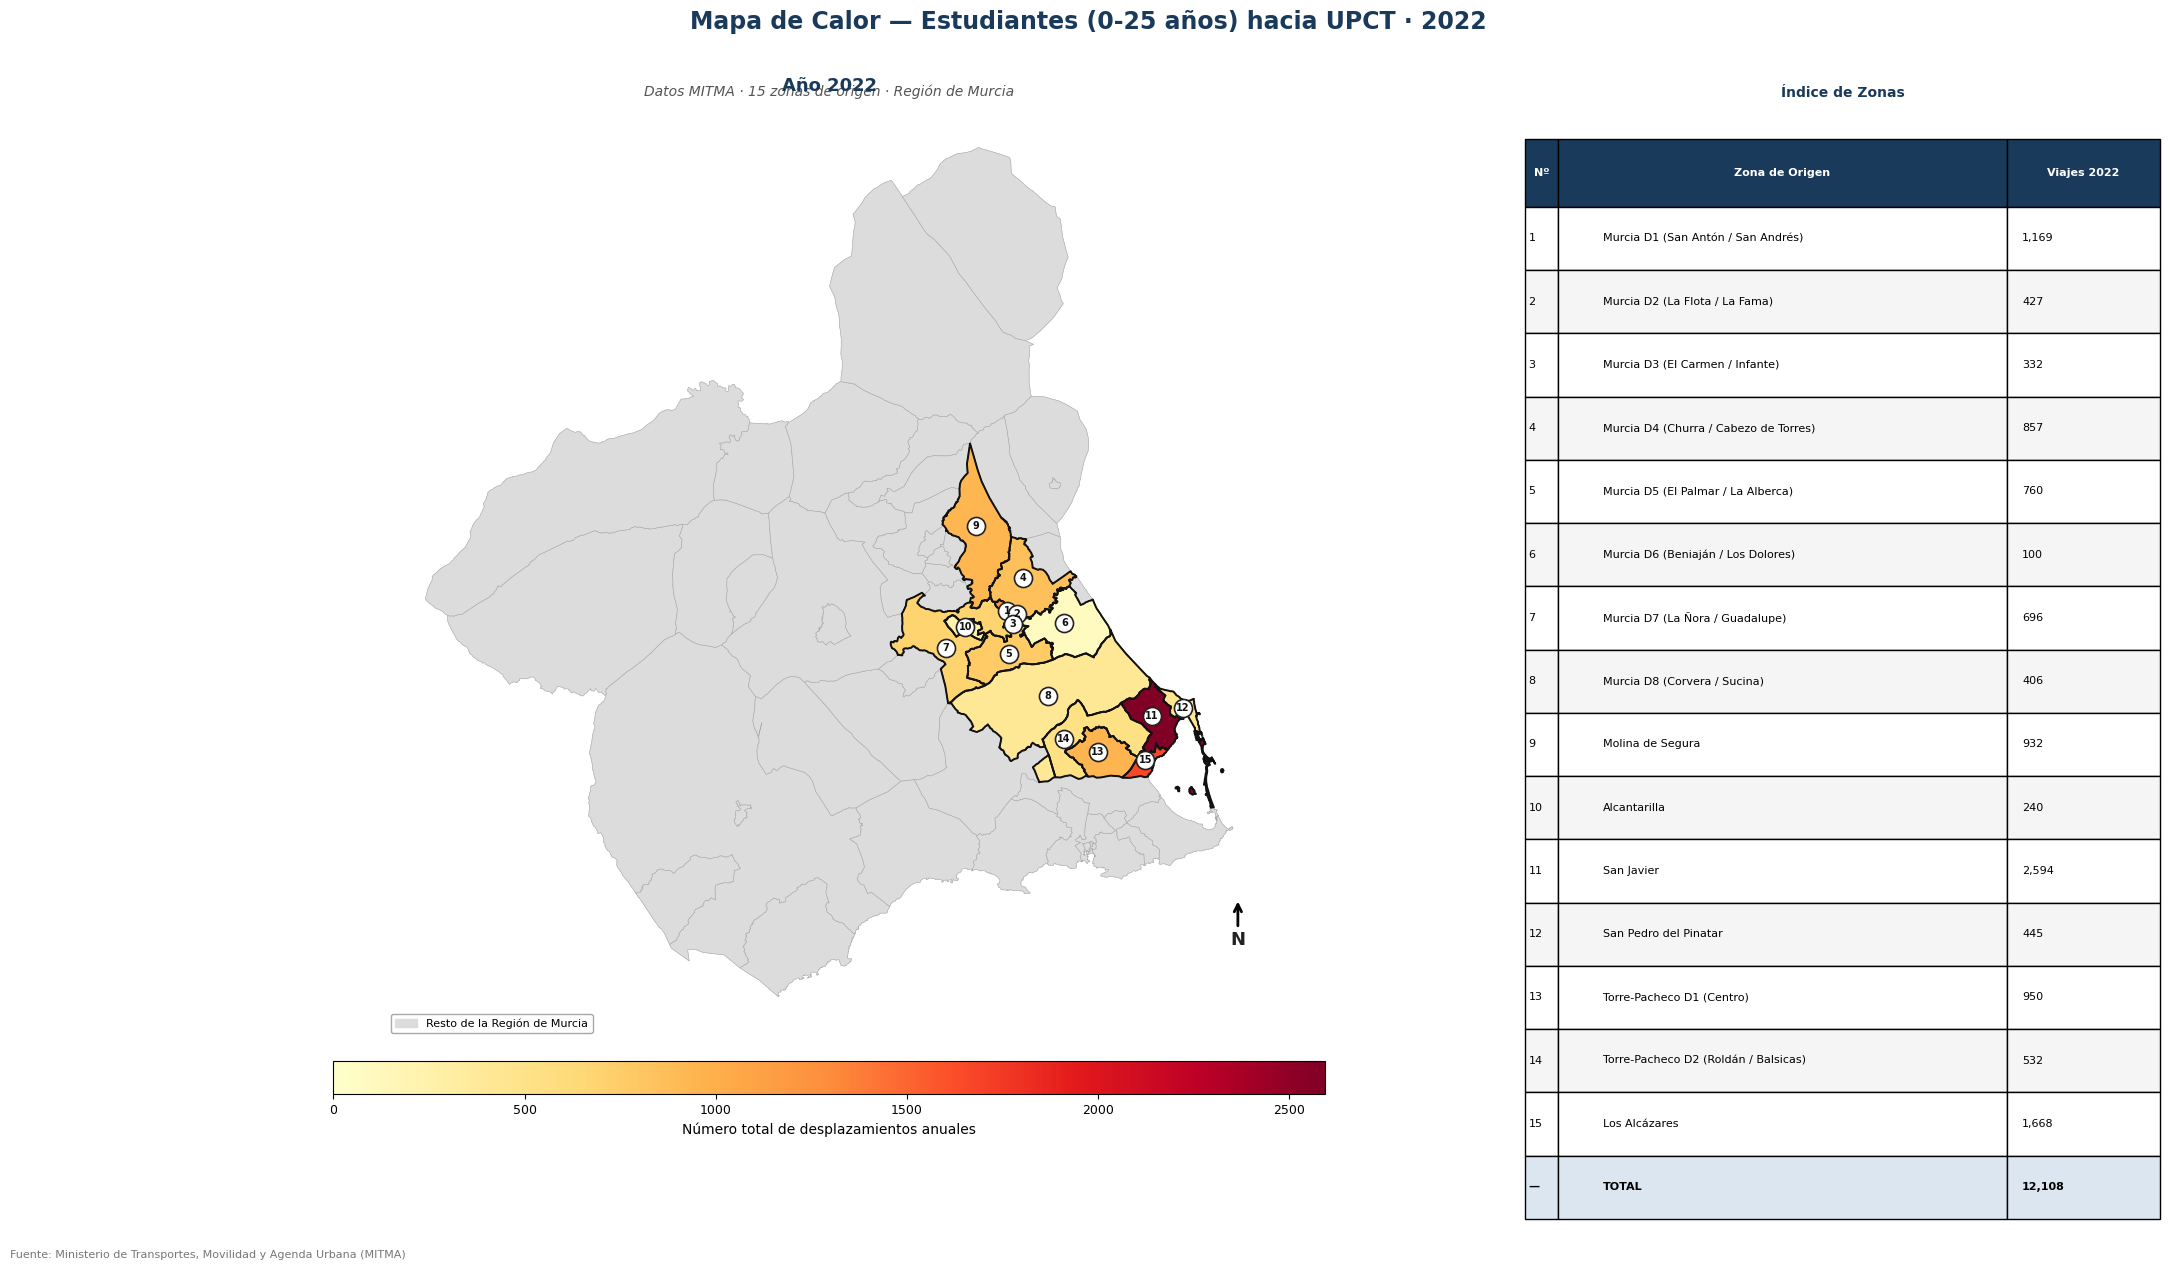

 Guardado: ../images/mapa_calor_2022.png


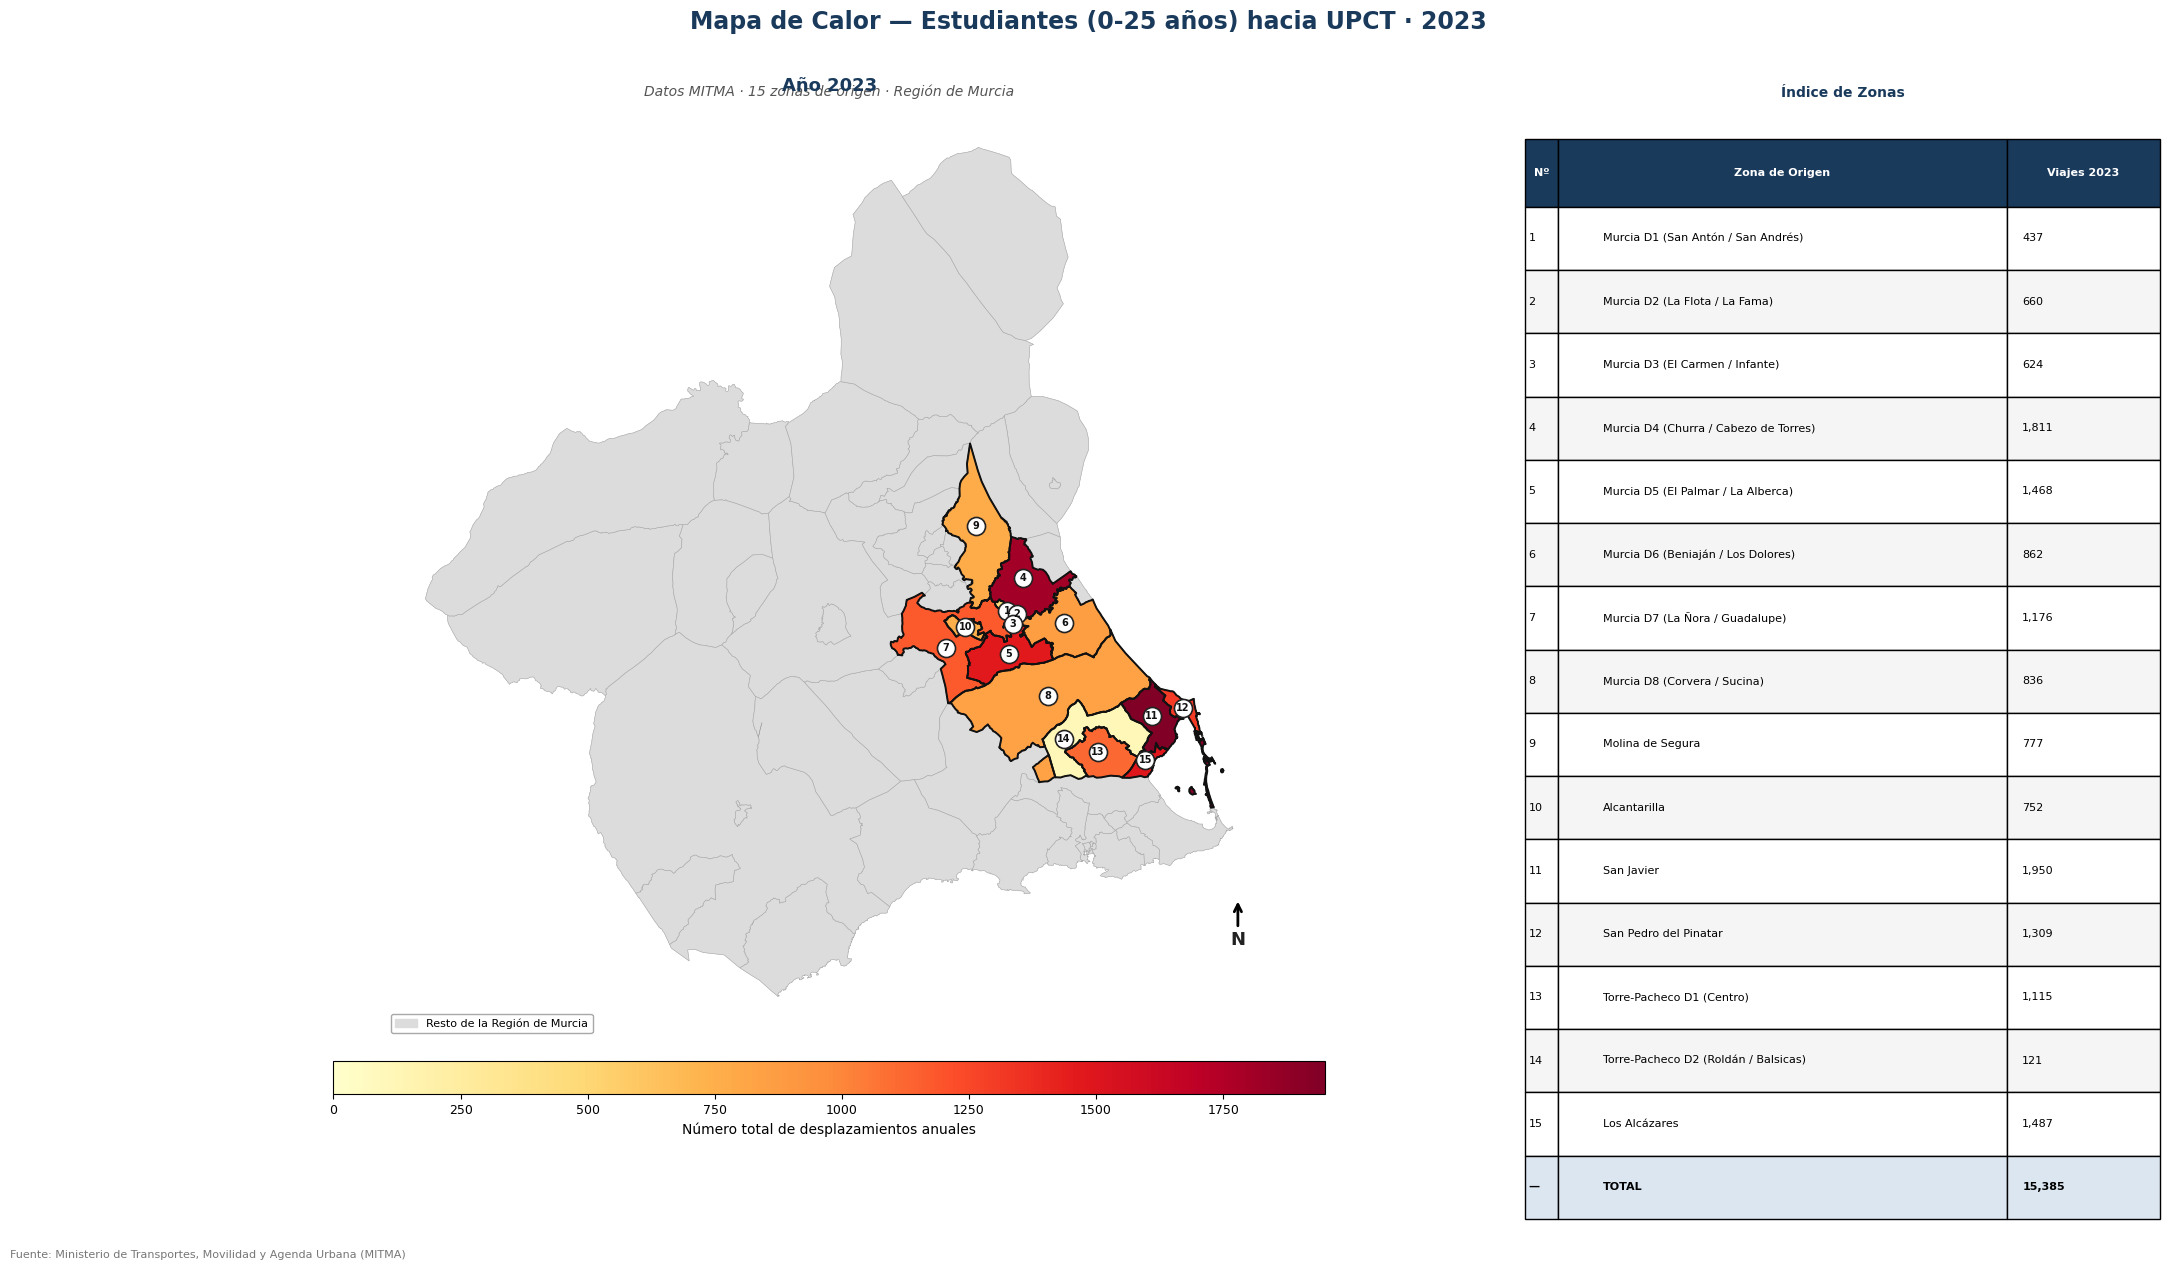

 Guardado: ../images/mapa_calor_2023.png


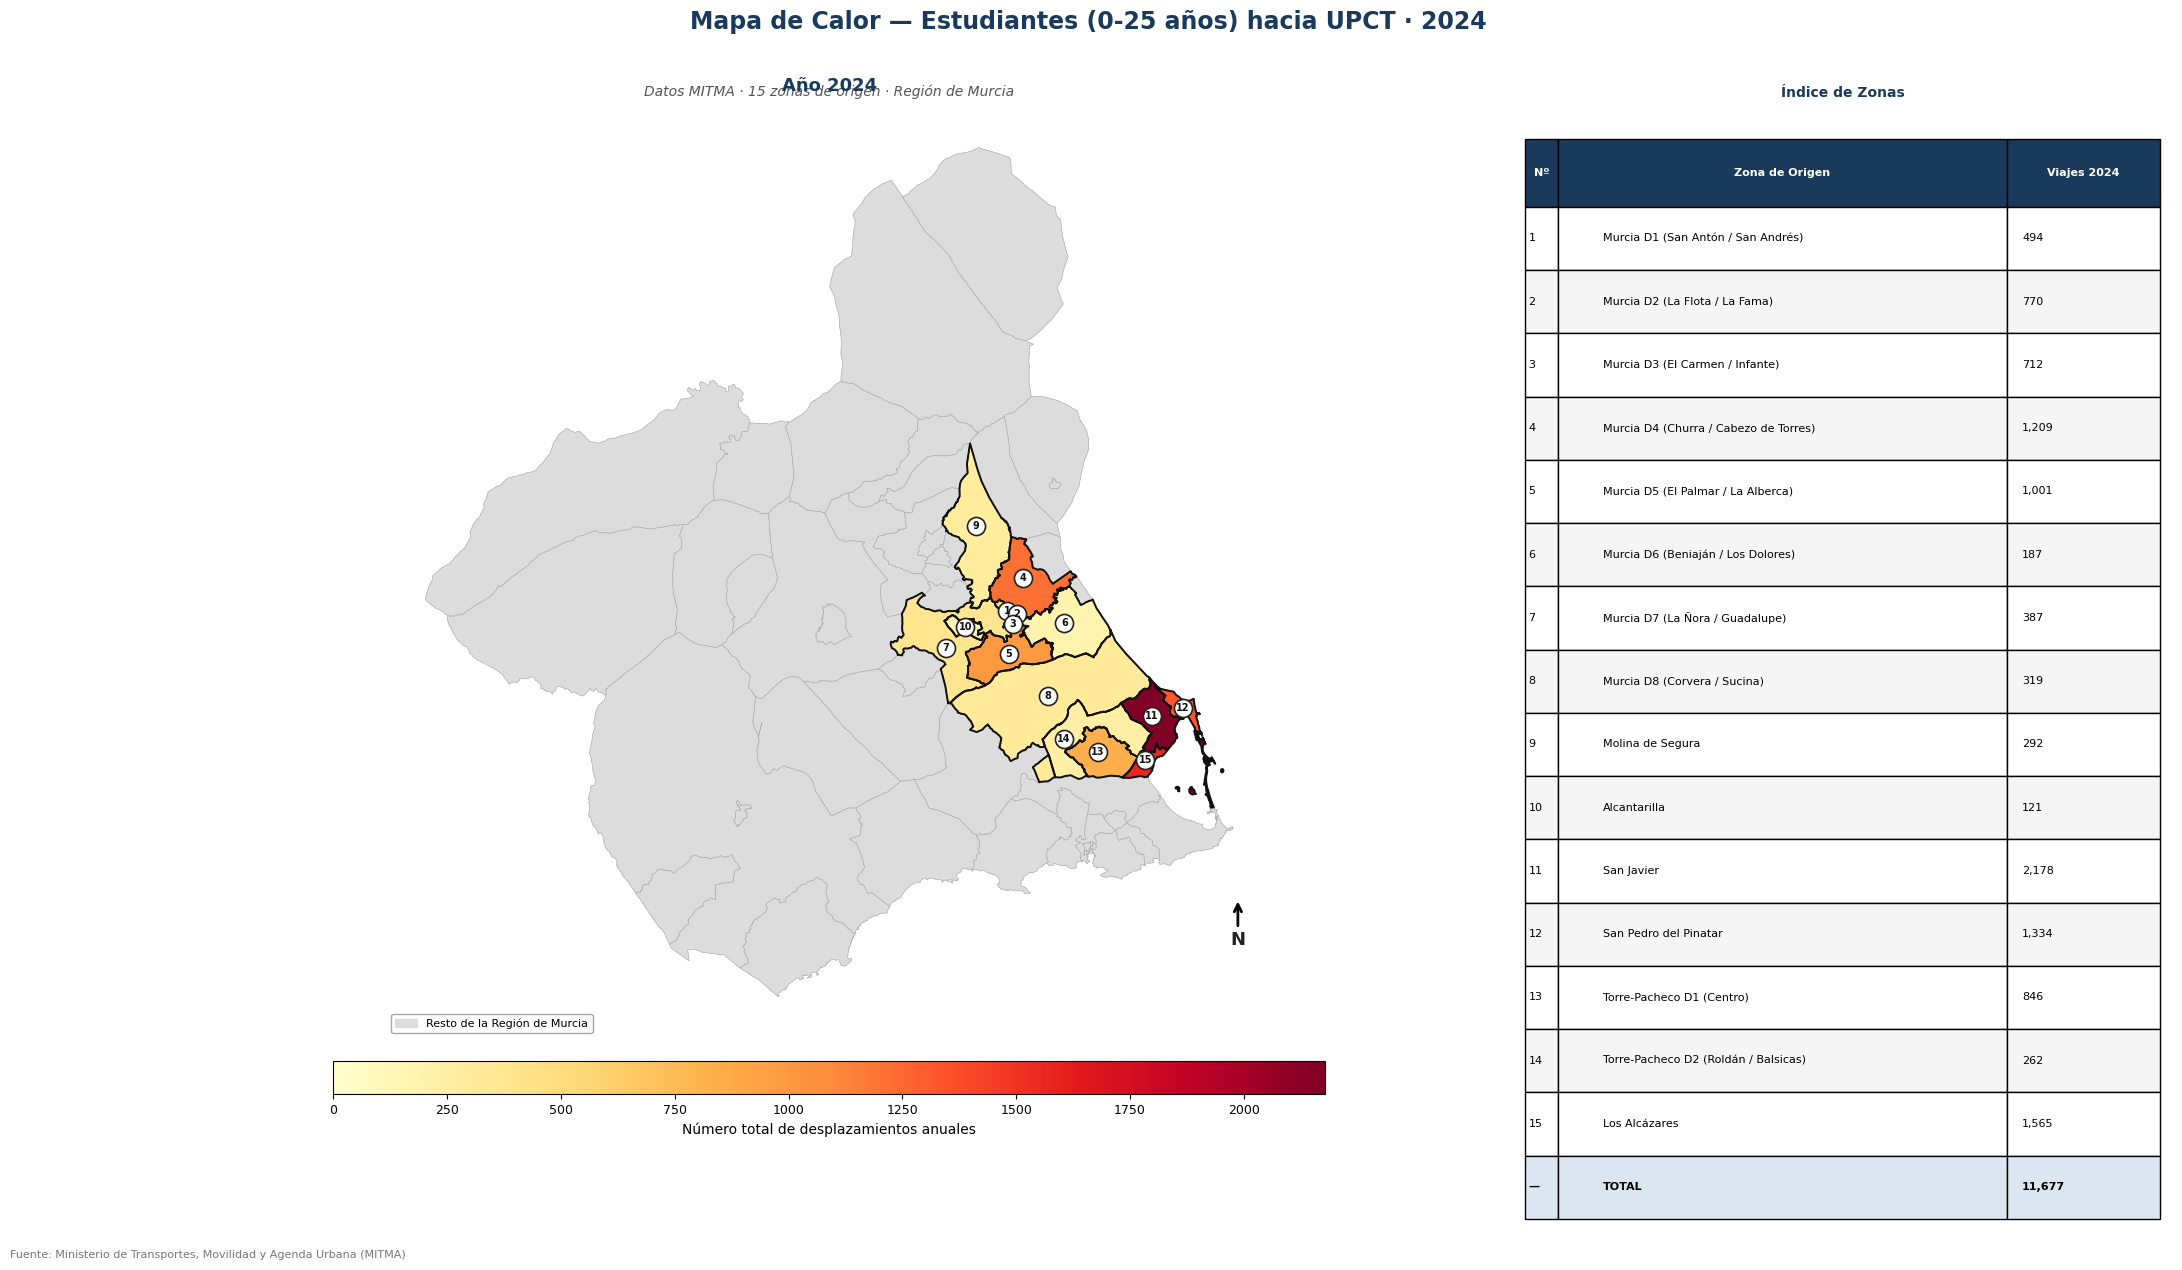

 Guardado: ../images/mapa_calor_2024.png


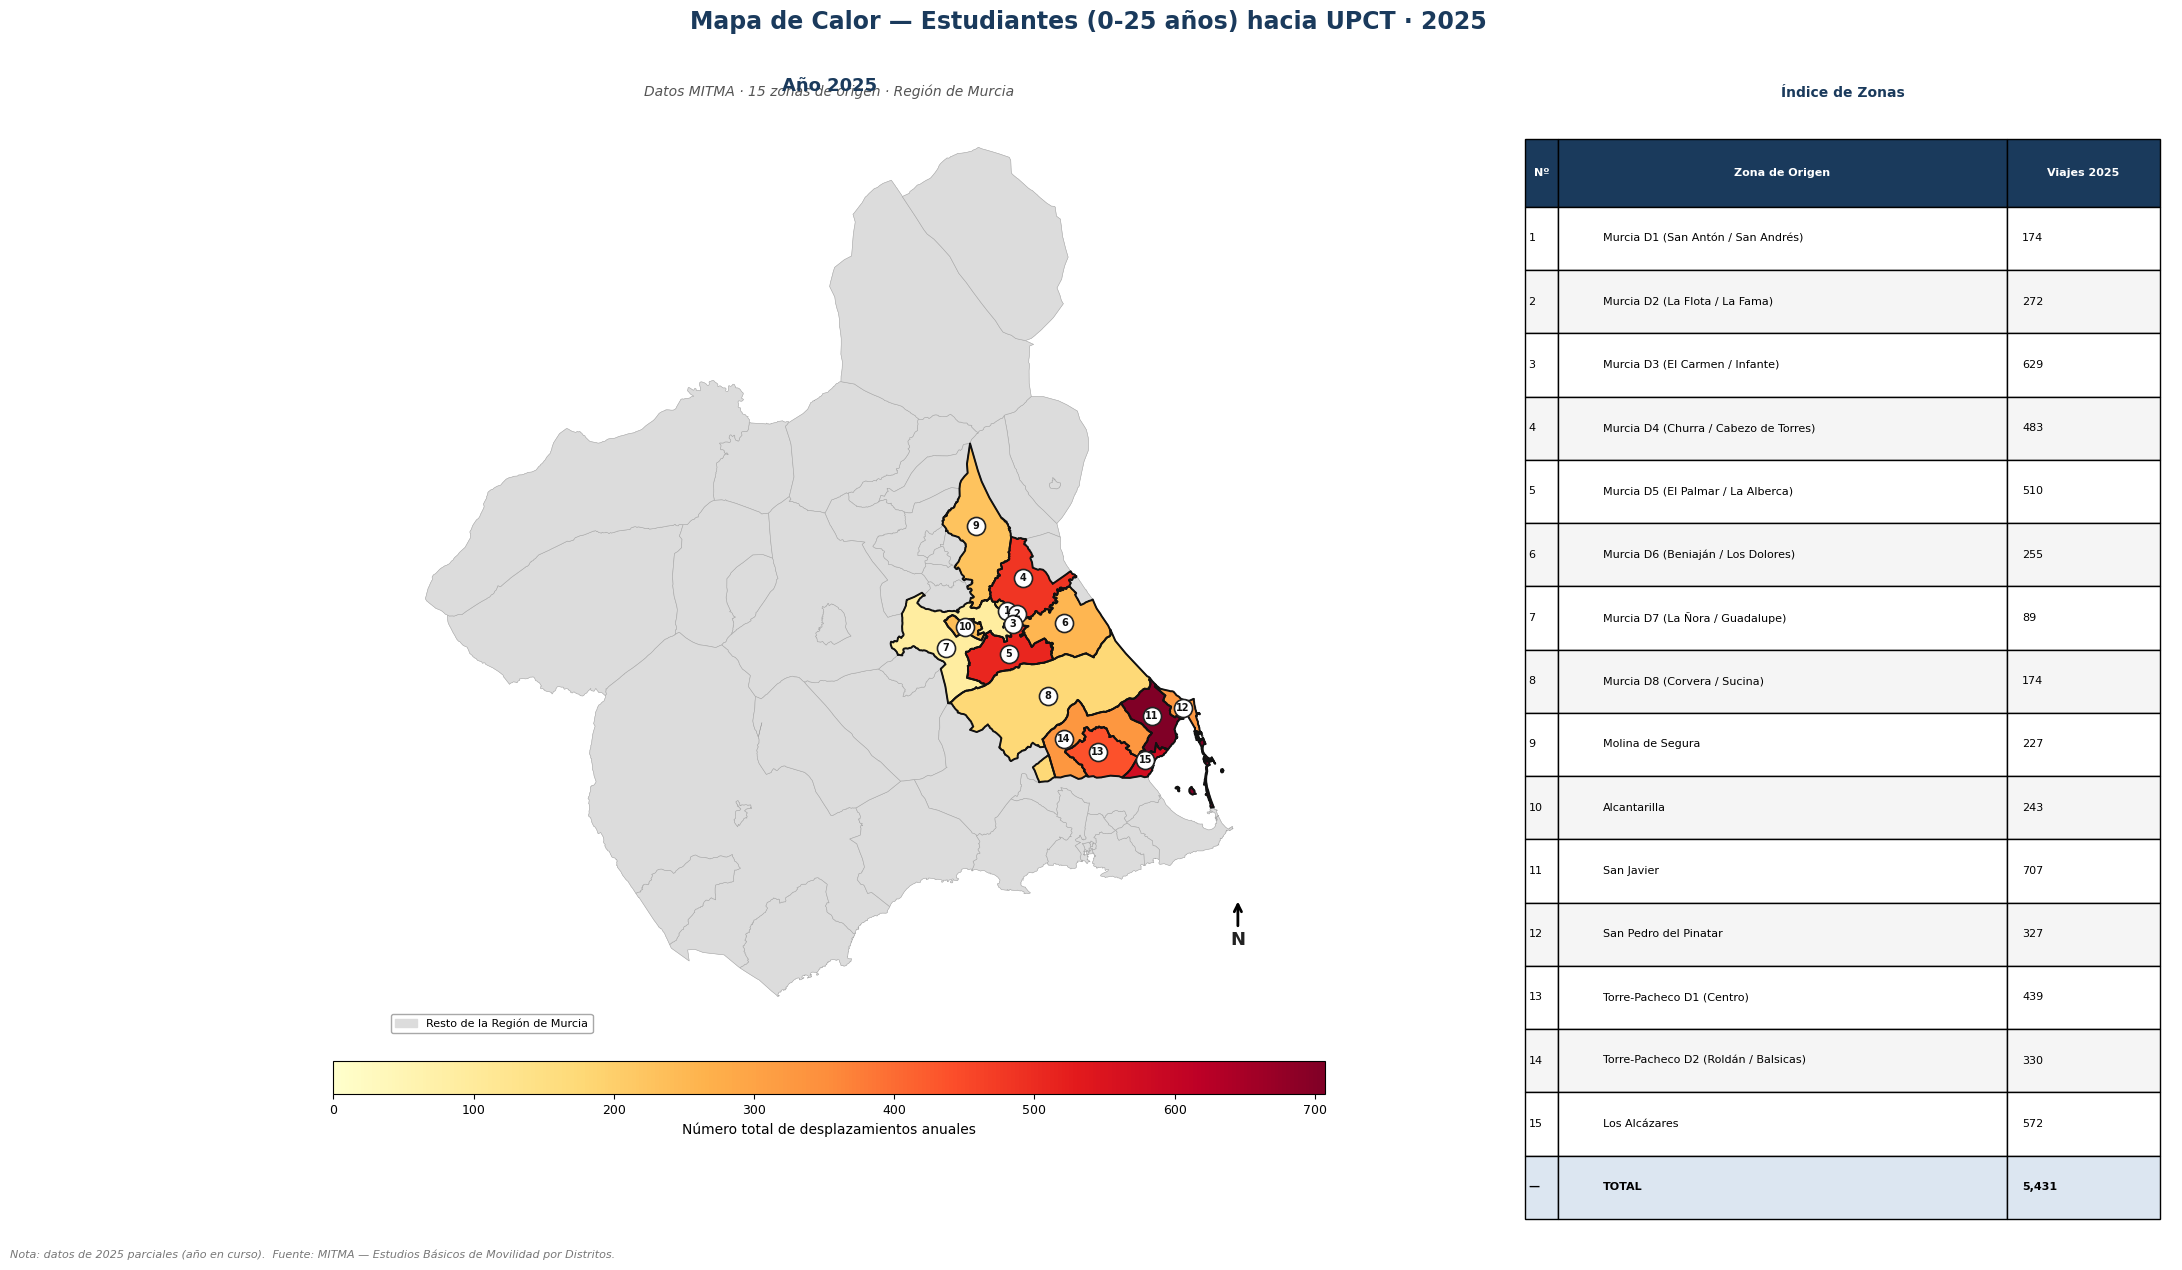

 Guardado: ../images/mapa_calor_2025.png


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# MAPAS ANUALES: 2022 · 2023 · 2024 · 2025
# ─────────────────────────────────────────────────────────────────────────────

def generar_mapa_anual(año):
    if año not in DATOS:
        print(f"Sin datos para {año} — omitido.")
        return

    fig, (ax_m, ax_t) = plt.subplots(
        1, 2, figsize=(22, 13),
        gridspec_kw={'width_ratios': [3, 1.2]}
    )
    fig.patch.set_facecolor('white')

    sm, md = dibujar_mapa_numerado(ax_m, DATOS[año], titulo=f'Año {año}')

    # Barra de color
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax_m, orientation='horizontal',
                       pad=0.02, shrink=0.60, aspect=30)
    cb.set_label('Número total de desplazamientos anuales', fontsize=10)
    cb.ax.tick_params(labelsize=9)

    # Leyenda zonas fuera del estudio
    ax_m.legend(
        handles=[mpatches.Patch(color='#dcdcdc', label='Resto de la Región de Murcia')],
        loc='lower left', fontsize=8, framealpha=0.85, edgecolor='#999'
    )

    # Tabla índice
    dibujar_tabla_indice(ax_t, md, año)

    # Títulos
    fig.suptitle(
        f'Mapa de Calor — Estudiantes (0-25 años) hacia UPCT · {año}',
        fontsize=17, fontweight='bold', color='#1a3a5c', y=0.97
    )
    ax_m.text(0.5, 1.01,
               'Datos MITMA · 15 zonas de origen · Región de Murcia',
               transform=ax_m.transAxes, ha='center',
               fontsize=10, style='italic', color='#555')
    if año == 2025:
        fig.text(0.01, 0.01,
                  f'Nota: datos de {año} parciales (año en curso).  '
                  'Fuente: MITMA — Estudios Básicos de Movilidad por Distritos.',
                  fontsize=8, color='#777', style='italic')
    else:
        fig.text(0.01, 0.01,
                  'Fuente: Ministerio de Transportes, Movilidad y Agenda Urbana (MITMA)',
                  fontsize=8, color='#777')

    plt.tight_layout(rect=[0, 0.02, 1, 0.96])
    fname = f'../images/mapa_calor_{año}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f" Guardado: {fname}")


for año in [2022, 2023, 2024, 2025]:
    generar_mapa_anual(año)

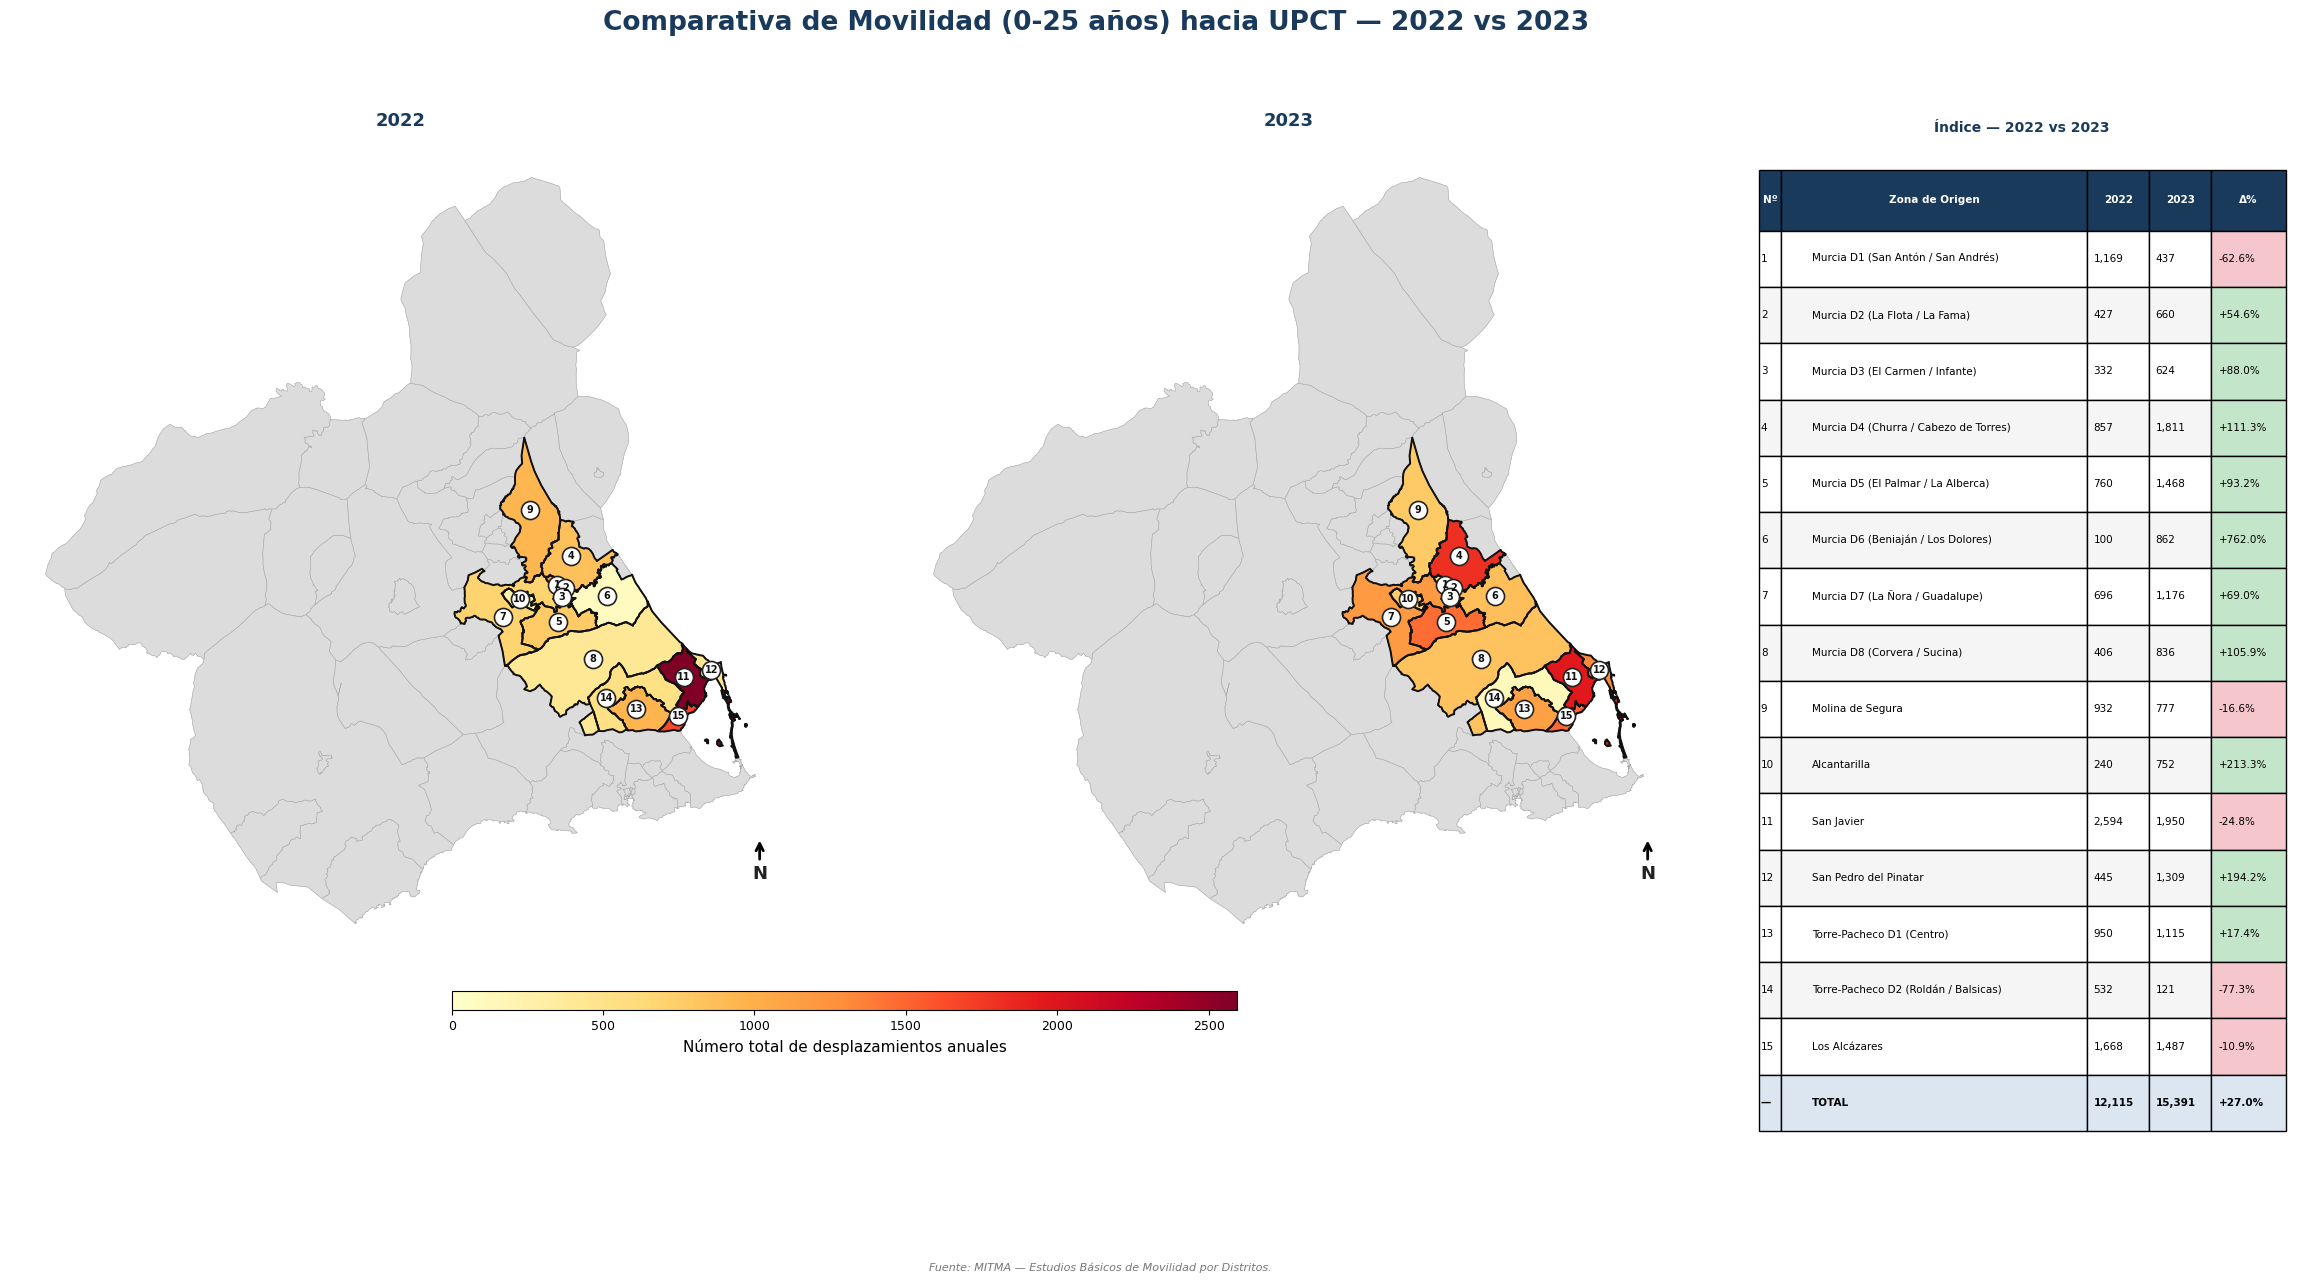

  ✓ Guardado: comparativa_2022_2023.png


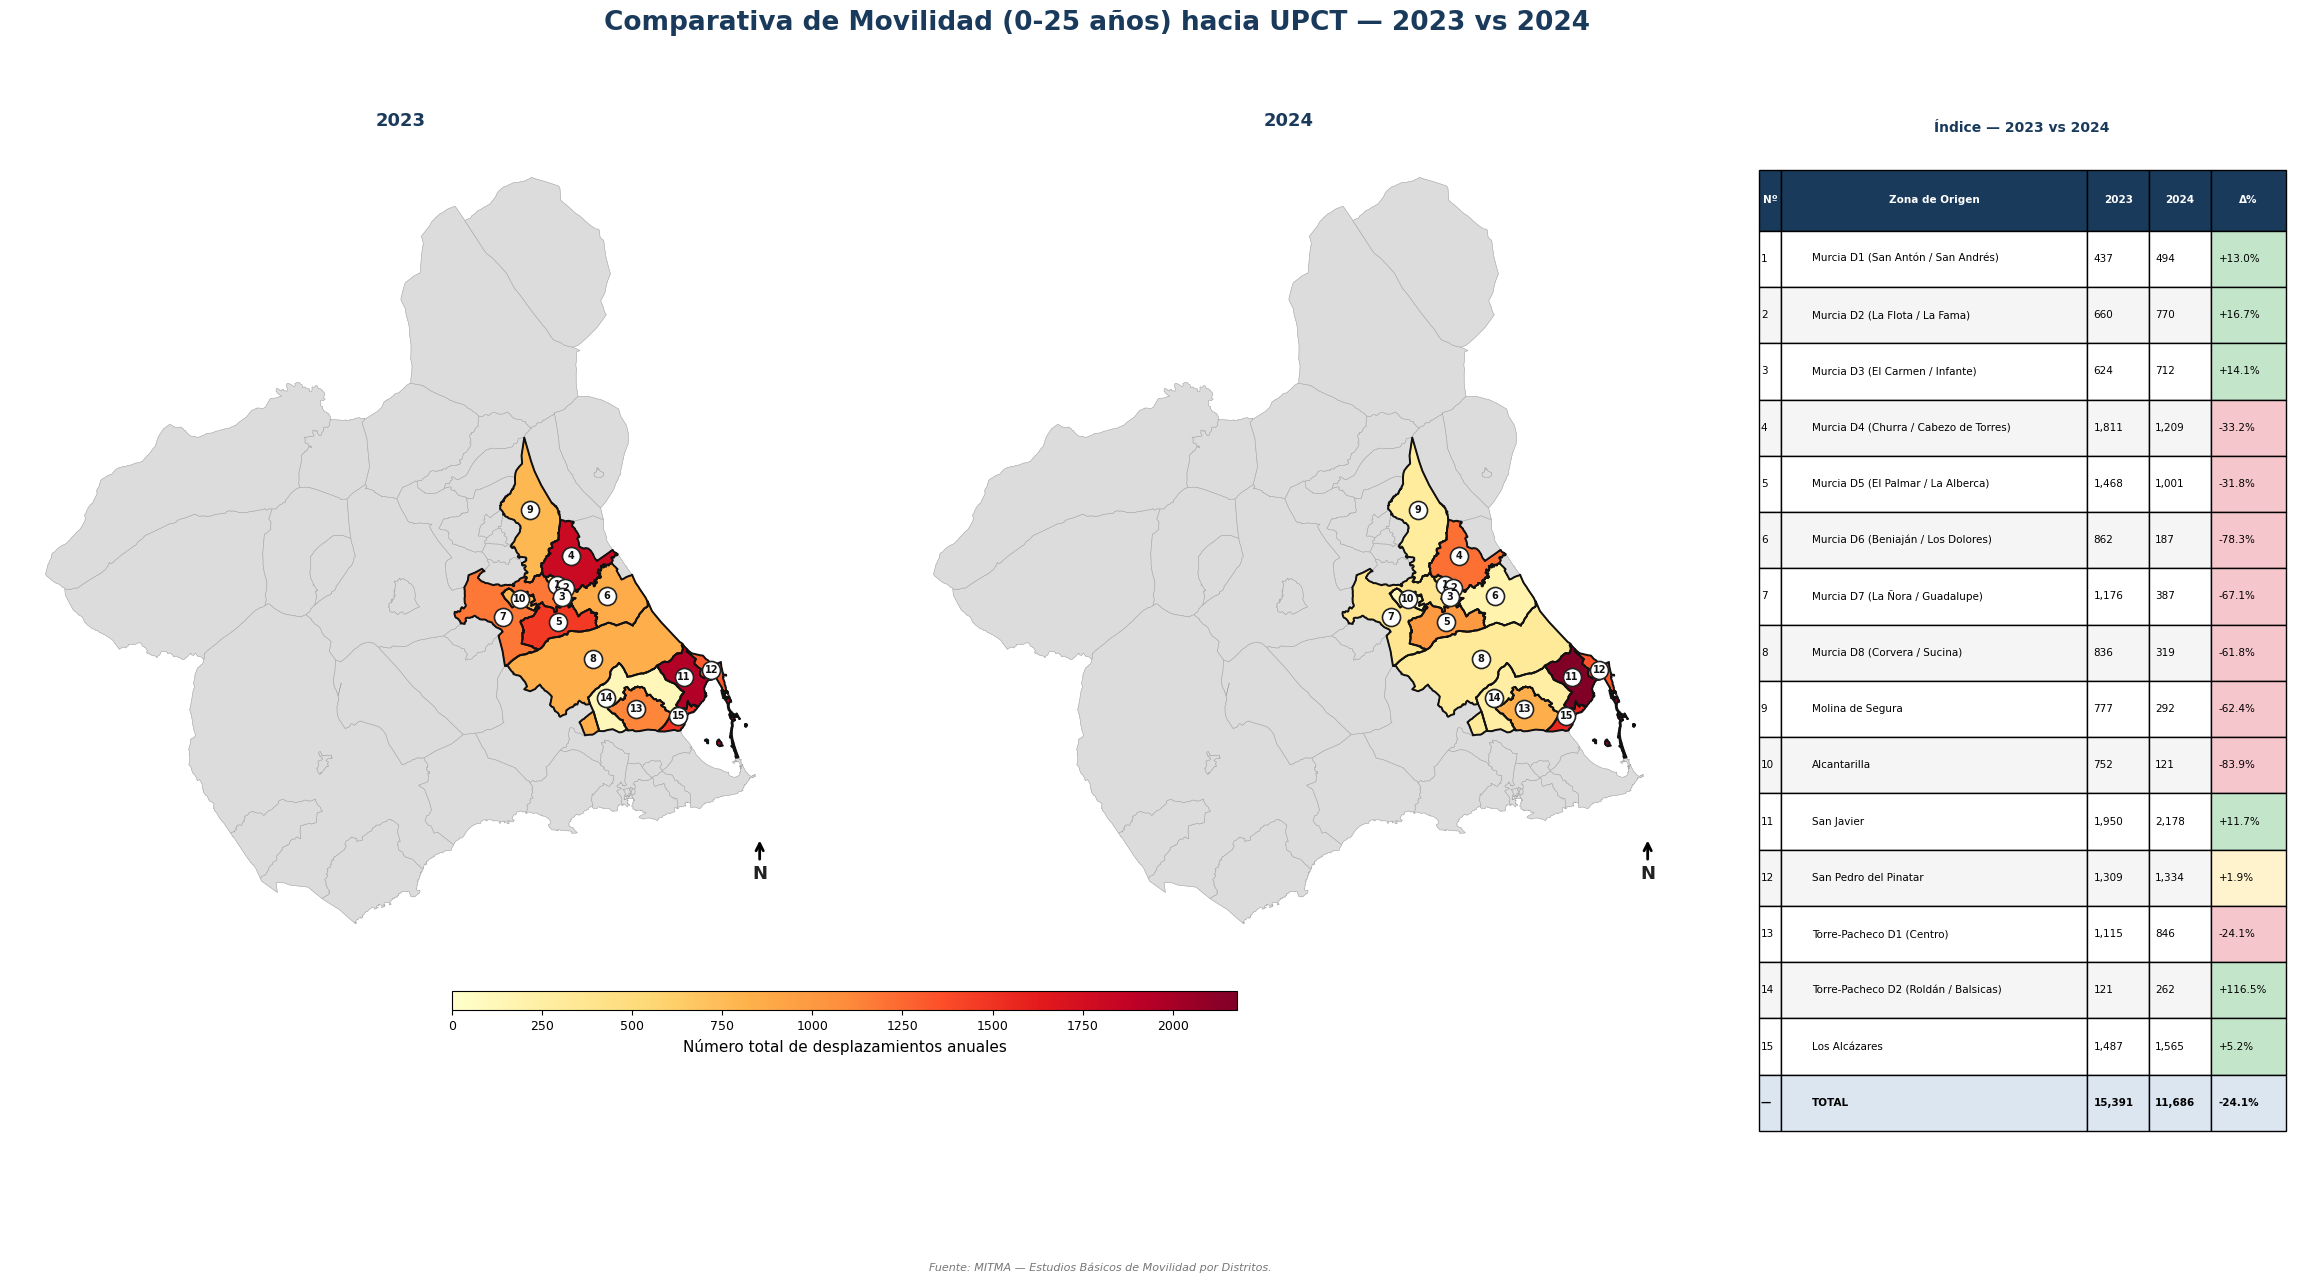

  ✓ Guardado: comparativa_2023_2024.png


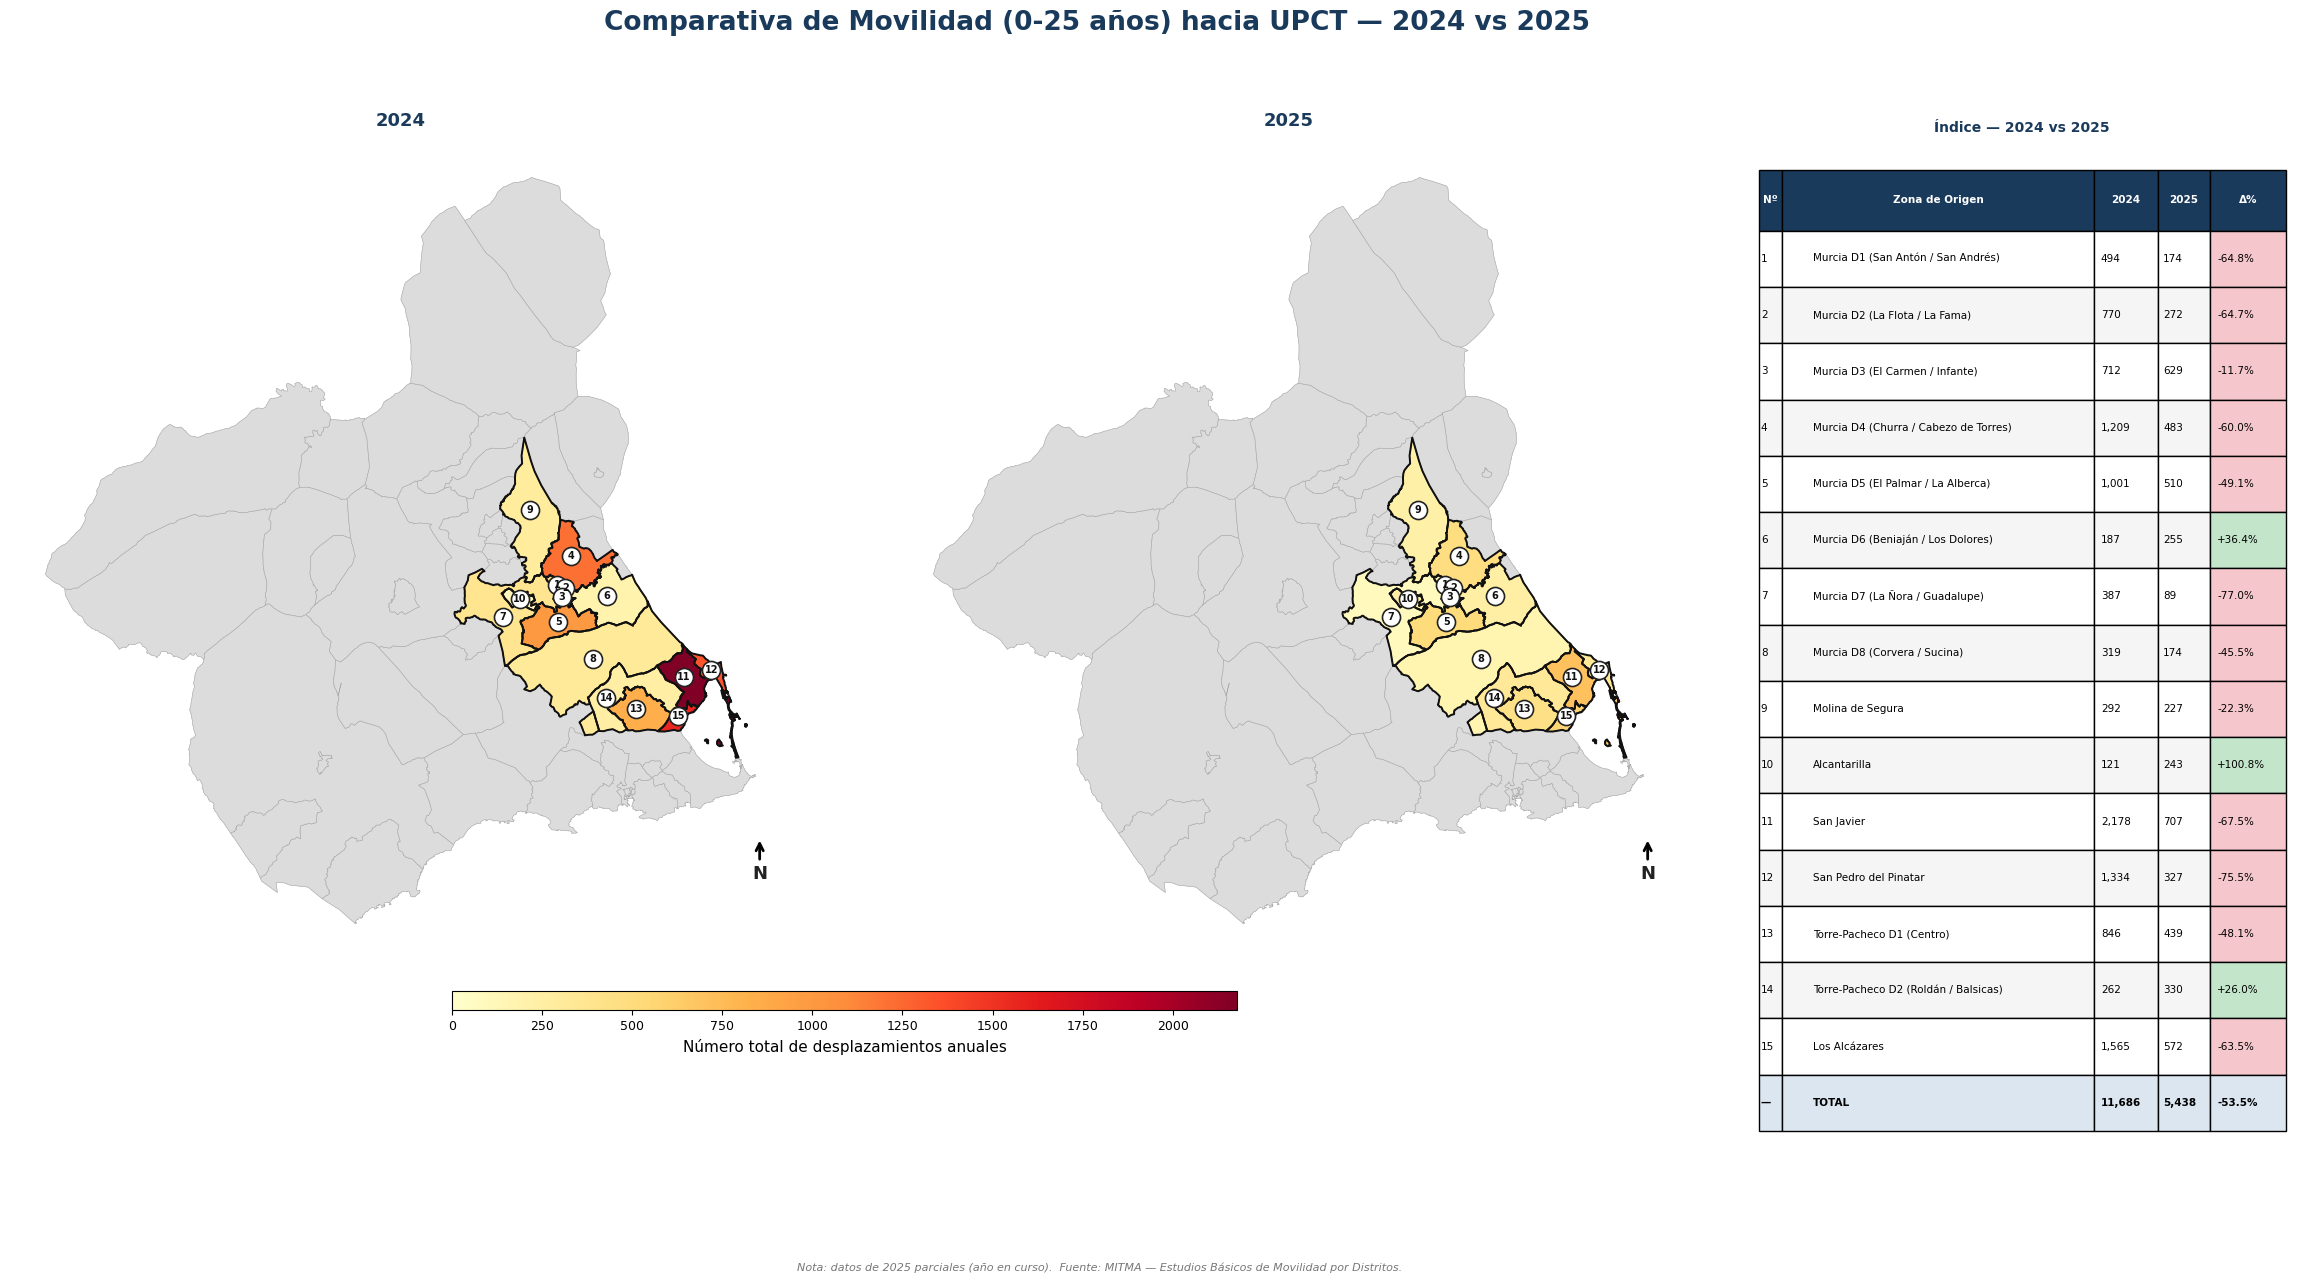

  ✓ Guardado: comparativa_2024_2025.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPARATIVAS: 2022-2023 · 2023-2024 · 2024-2025
# ─────────────────────────────────────────────────────────────────────────────

def generar_comparativa(año_a, año_b):
    faltantes = [a for a in (año_a, año_b) if a not in DATOS]
    if faltantes:
        print(f"    Sin datos para {faltantes} — comparativa {año_a} vs {año_b} omitida.")
        return

    vmax = max(
        DATOS[año_a][DATOS[año_a]['origen'].isin(ZONAS_ESTUDIO)]['viajes'].max(),
        DATOS[año_b][DATOS[año_b]['origen'].isin(ZONAS_ESTUDIO)]['viajes'].max()
    )

    fig = plt.figure(figsize=(30, 13))
    fig.patch.set_facecolor('white')
    gs = fig.add_gridspec(1, 3, width_ratios=[2.5, 2.5, 1.6], wspace=0.04)
    ax_a, ax_b, ax_t = (fig.add_subplot(gs[i]) for i in range(3))

    sm_a, md_a = dibujar_mapa_numerado(ax_a, DATOS[año_a], vmax=vmax, titulo=str(año_a))
    sm_b, md_b = dibujar_mapa_numerado(ax_b, DATOS[año_b], vmax=vmax, titulo=str(año_b))

    # Barra de color compartida
    sm_a.set_array([])
    cb = fig.colorbar(sm_a, ax=[ax_a, ax_b], orientation='horizontal',
                       pad=0.03, shrink=0.45, aspect=40)
    cb.set_label('Número total de desplazamientos anuales', fontsize=11)
    cb.ax.tick_params(labelsize=9)

    # Tabla comparativa con variación
    dibujar_tabla_comparativa(ax_t, md_a, md_b, año_a, año_b)

    fig.suptitle(
        f'Comparativa de Movilidad (0-25 años) hacia UPCT — {año_a} vs {año_b}',
        fontsize=19, fontweight='bold', color='#1a3a5c', y=0.98
    )
    nota_parcial = '  Nota: datos de 2025 parciales (año en curso).'
    fuente = 'Fuente: MITMA — Estudios Básicos de Movilidad por Distritos.'
    fig.text(0.5, 0.01,
              (nota_parcial if 2025 in (año_a, año_b) else '') + '  ' + fuente,
              ha='center', fontsize=8, color='#777', style='italic')
    fname = f'../images/comparativa_{año_a}_{año_b}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()


for par in [(2022, 2023), (2023, 2024), (2024, 2025)]:
    generar_comparativa(*par)

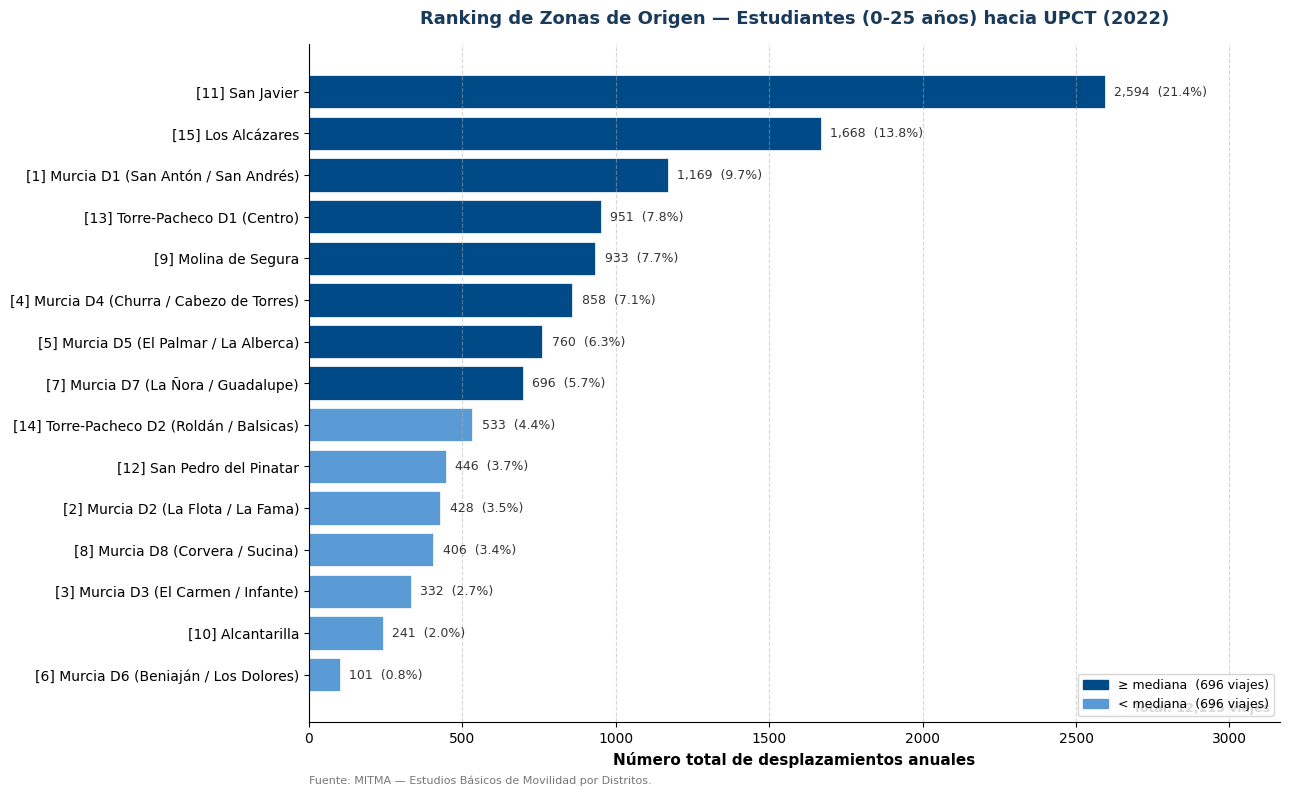

  ✓ Guardado: ranking_zonas_2022.png


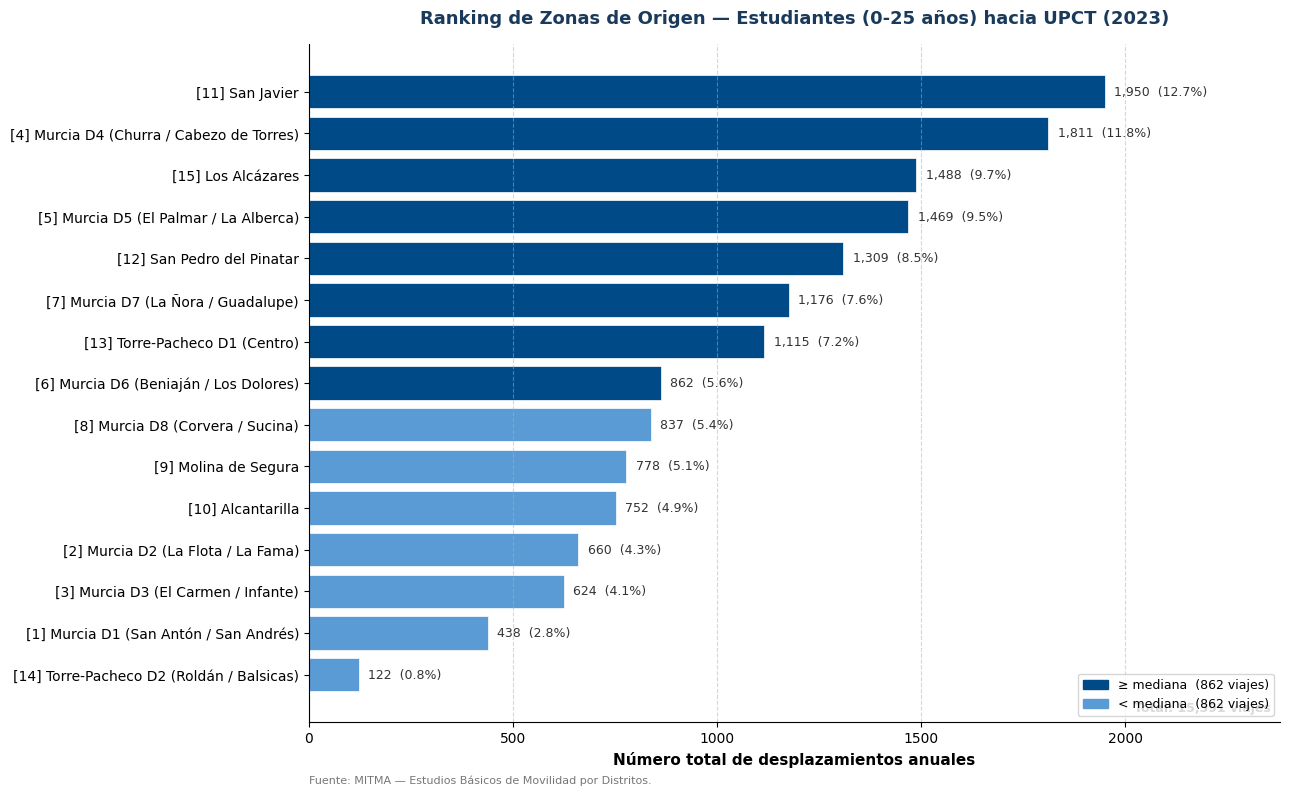

  ✓ Guardado: ranking_zonas_2023.png


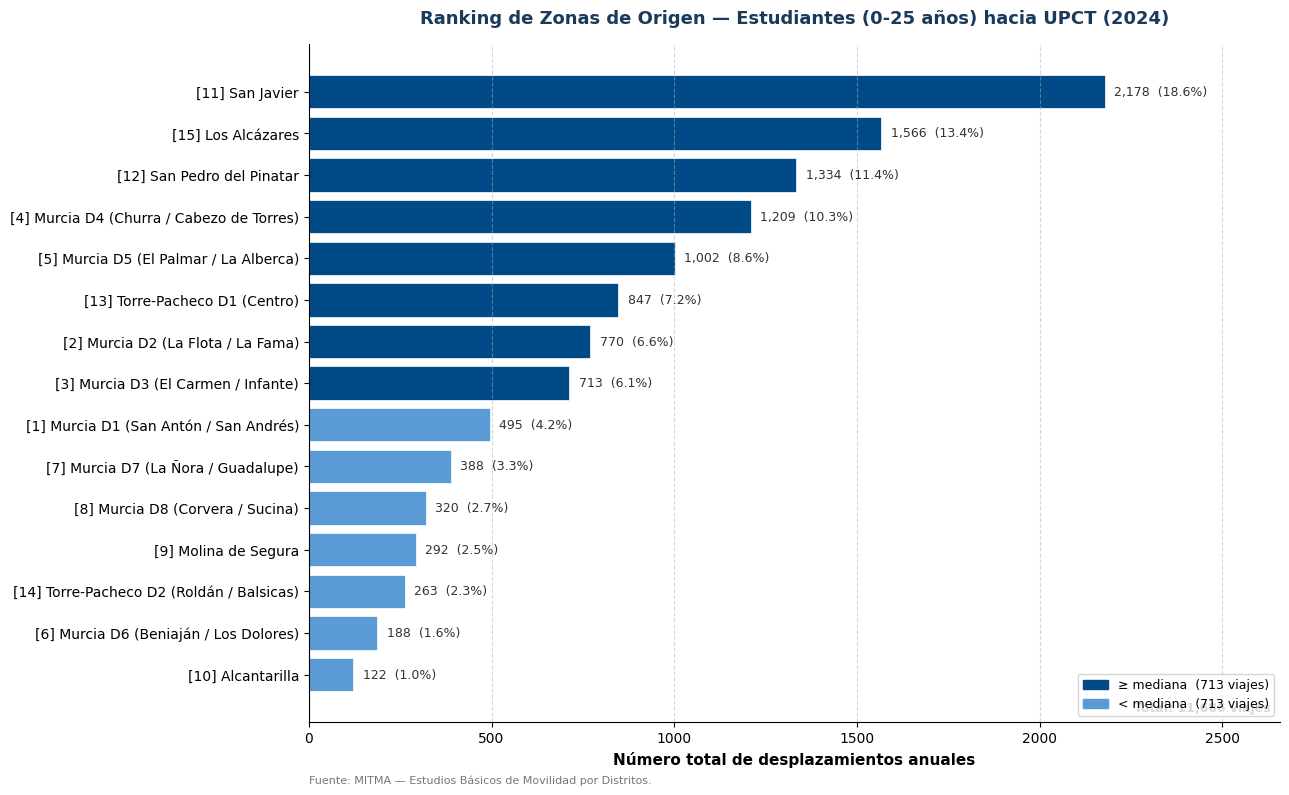

  ✓ Guardado: ranking_zonas_2024.png


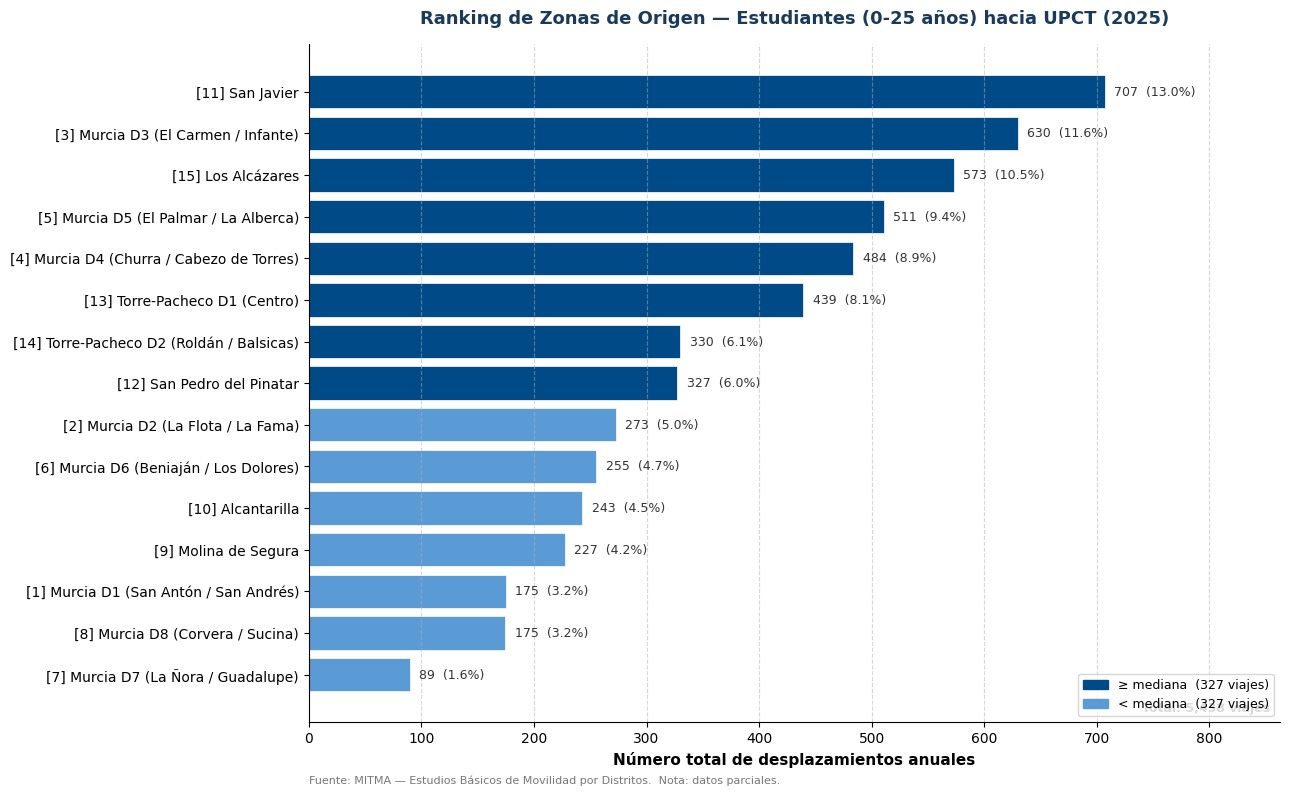

  ✓ Guardado: ranking_zonas_2025.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# RANKINGS DE ZONAS: 2022 · 2023 · 2024 · 2025
# ─────────────────────────────────────────────────────────────────────────────

def generar_ranking(año):
    if año not in DATOS:
        print(f"    Sin datos para {año} — omitido.")
        return

    df = (DATOS[año][DATOS[año]['origen'].isin(ZONAS_ESTUDIO)]
          .copy()
          .assign(
              nombre = lambda x: x['origen'].map(NOMBRES_TABLA),
              num    = lambda x: x['origen'].map(INDICE_ZONAS),
              pct    = lambda x: (x['viajes'] / x['viajes'].sum() * 100).round(1)
          )
          .sort_values('viajes', ascending=True))

    mediana = df['viajes'].median()
    colores = ['#004b87' if v >= mediana else '#5b9bd5' for v in df['viajes']]
    etiq_y  = [f"[{int(r['num'])}] {r['nombre']}" for _, r in df.iterrows()]

    fig, ax = plt.subplots(figsize=(13, 8))
    fig.patch.set_facecolor('white')

    bars = ax.barh(etiq_y, df['viajes'], color=colores,
                    edgecolor='white', linewidth=0.5)

    xmax = df['viajes'].max()
    for bar, val, pct in zip(bars, df['viajes'], df['pct']):
        ax.text(
            val + xmax * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}  ({pct}%)',
            va='center', ha='left', fontsize=9, color='#333'
        )

    ax.set_xlim(0, xmax * 1.22)
    ax.set_xlabel('Número total de desplazamientos anuales',
                   fontsize=11, fontweight='bold')
    ax.set_title(
        f'Ranking de Zonas de Origen — Estudiantes (0-25 años) hacia UPCT ({año})',
        fontsize=13, fontweight='bold', color='#1a3a5c', pad=15
    )
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(
        handles=[
            mpatches.Patch(color='#004b87', label=f'≥ mediana  ({mediana:,.0f} viajes)'),
            mpatches.Patch(color='#5b9bd5', label=f'< mediana  ({mediana:,.0f} viajes)')
        ],
        fontsize=9, loc='lower right'
    )

    total = int(df['viajes'].sum())
    ax.text(0.99, 0.015, f'Total: {total:,} viajes',
             transform=ax.transAxes, ha='right', fontsize=9,
             color='#444', fontweight='bold')

    nota = '  Nota: datos parciales.' if año == 2025 else ''
    ax.text(0.0, -0.09,
             f'Fuente: MITMA — Estudios Básicos de Movilidad por Distritos.{nota}',
             transform=ax.transAxes, fontsize=8, color='#777')

    plt.tight_layout()
    fname = f'../images/ranking_zonas_{año}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()


for año in [2022, 2023, 2024, 2025]:
    generar_ranking(año)

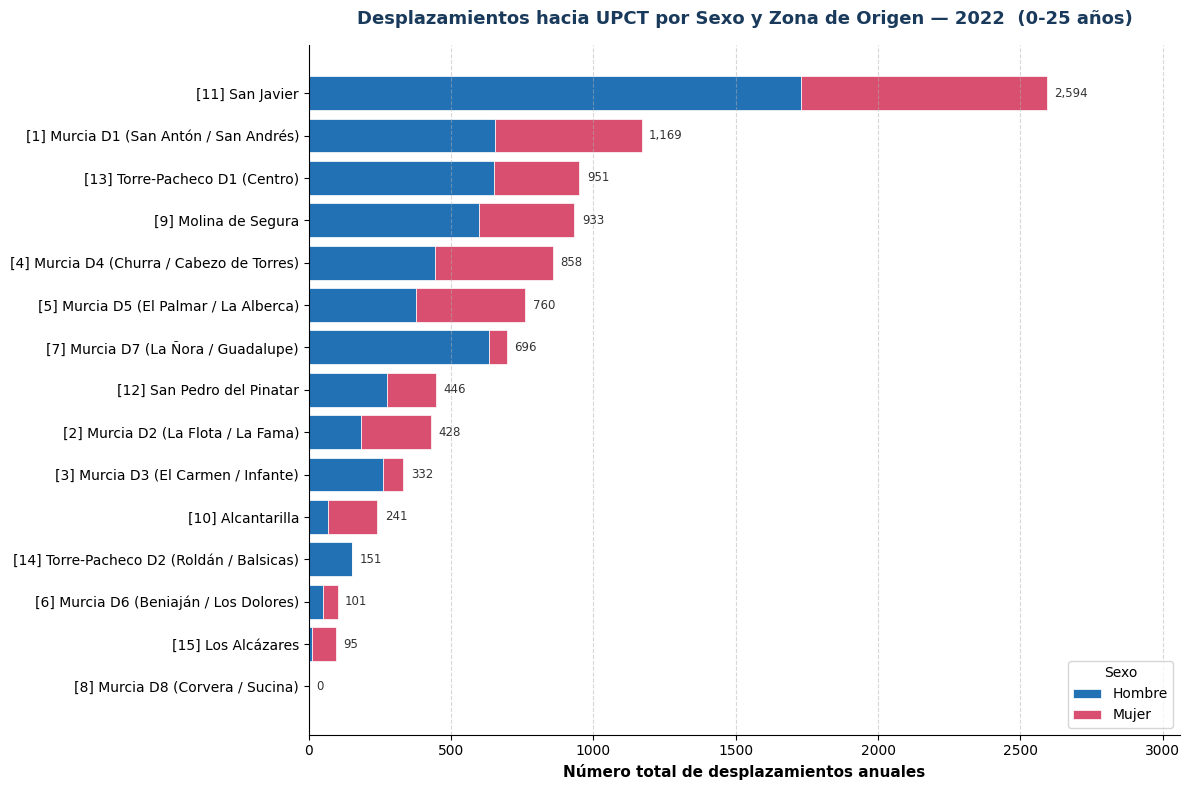

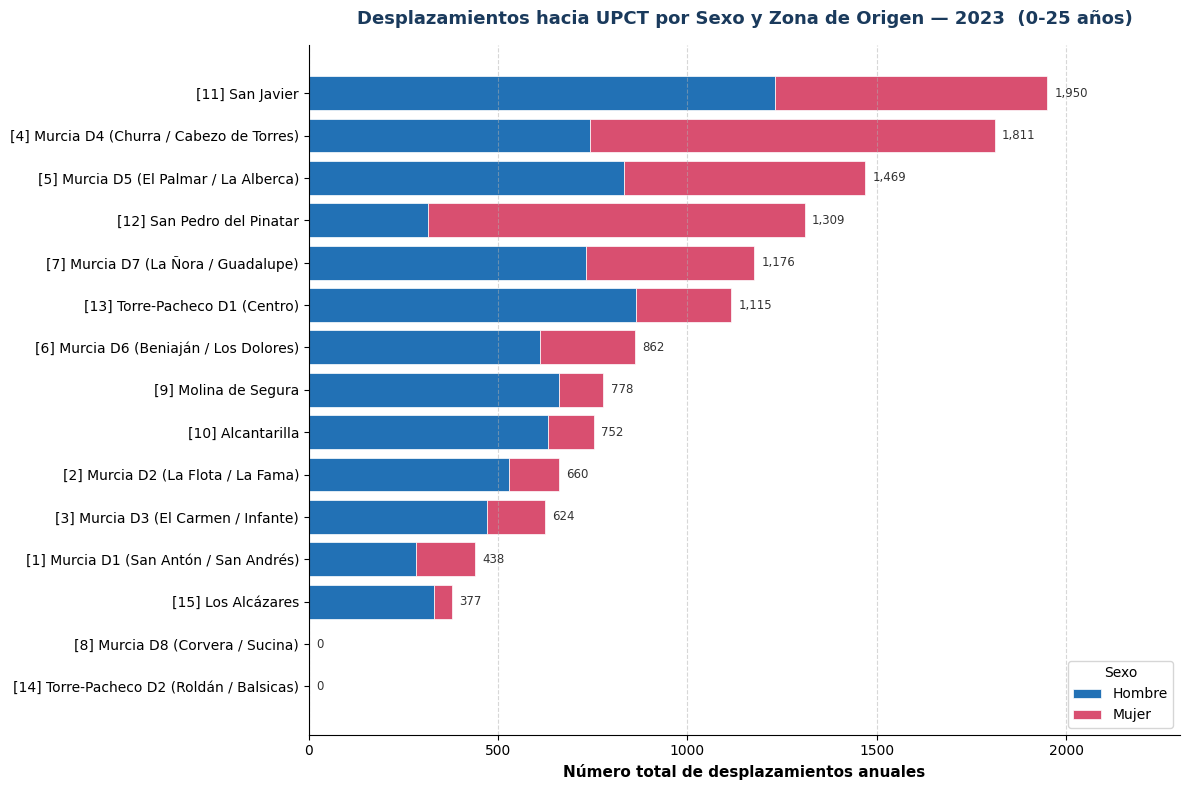

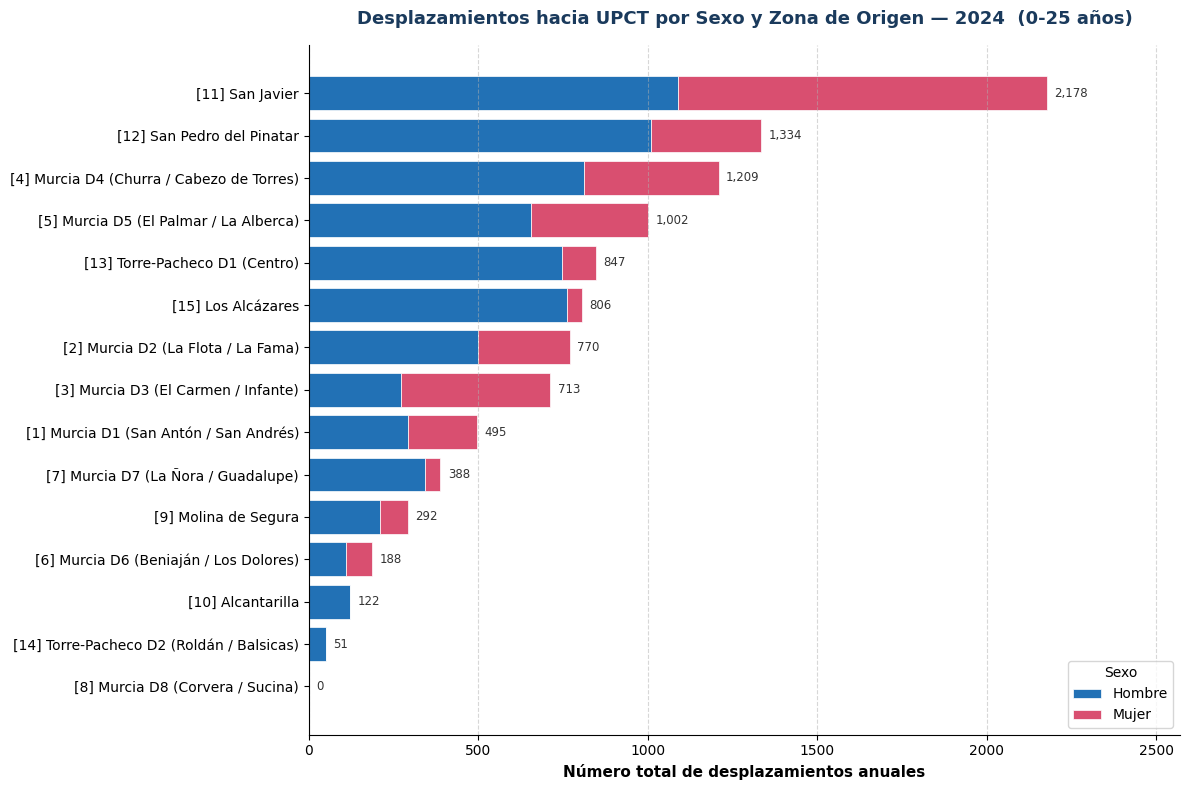

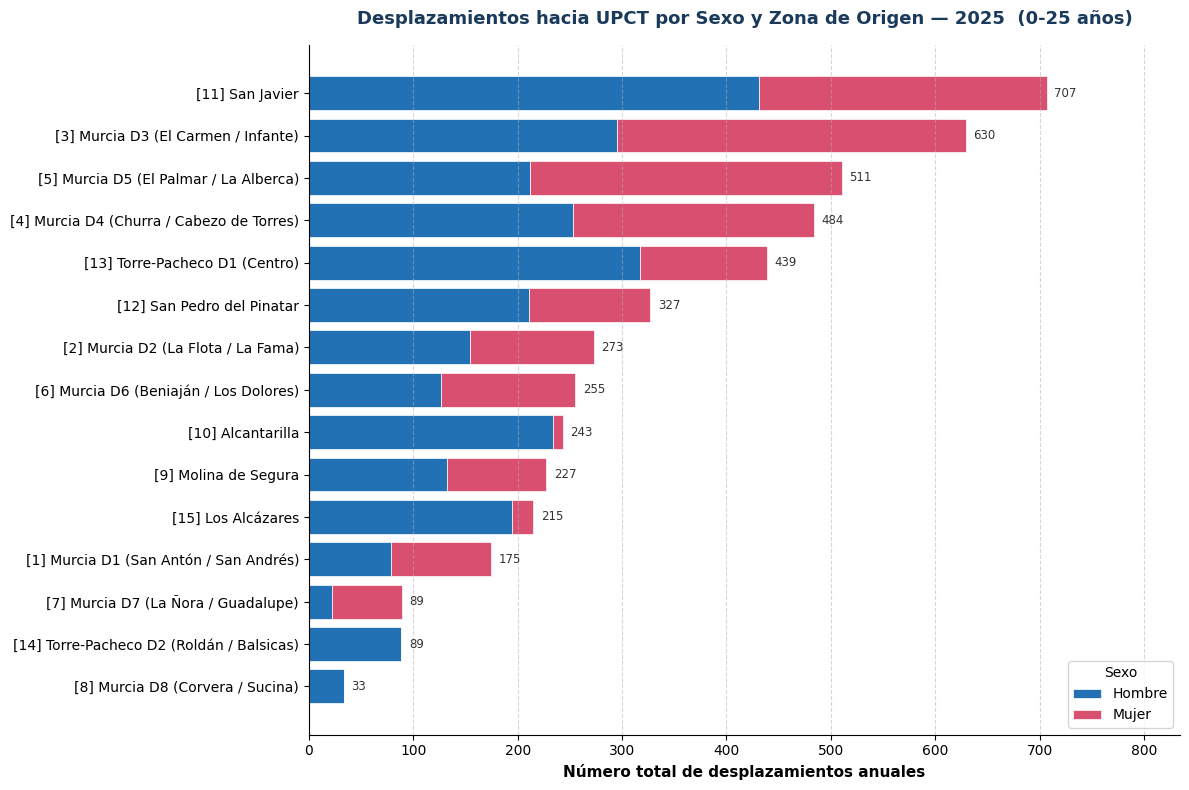

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# DESGLOSE POR SEXO (VERSIÓN CORREGIDA Y BLINDADA)
# ─────────────────────────────────────────────────────────────────────────────

COLORES_SEXO = {'hombre': '#2271b5', 'mujer': '#d94f70'}

for año in sorted(DATOS.keys()):
    ruta = f'..//data//viajes_murcia_cartagena_{año}.parquet'
    if not os.path.exists(ruta):
        continue
        
    df_raw = pd.read_parquet(ruta)
    
    # CORRECCIÓN 1: Comas y números
    df_raw['viajes'] = pd.to_numeric(df_raw['viajes'].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)
    
    # CORRECCIÓN 2: Limpieza del ID de origen
    df_raw['origen'] = df_raw['origen'].astype(str).str.strip()

    if 'sexo' not in df_raw.columns:
        print(f"  ⚠  {año}: columna 'sexo' no encontrada — celda omitida.")
        continue

    # CORRECCIÓN 3: Normalización de la columna sexo (minúsculas y sin espacios)
    df_raw['sexo'] = df_raw['sexo'].astype(str).str.strip().str.lower()

    # Ahora sí podemos filtrar seguros
    df_z = df_raw[df_raw['origen'].isin(ZONAS_ESTUDIO)].copy()

    pivot = (
        df_z.groupby(['origen', 'sexo'])['viajes']
        .sum().unstack(fill_value=0).reset_index()
    )
    
    pivot['etiq'] = pivot['origen'].apply(
        lambda x: f"[{INDICE_ZONAS.get(x, '?')}] {NOMBRES_TABLA.get(x, x)}"
    )
    pivot = pivot.set_index('etiq').drop(columns='origen')

    sexos = [s for s in ['hombre', 'mujer'] if s in pivot.columns]
    pivot_s = pivot.loc[pivot[sexos].sum(axis=1).sort_values(ascending=True).index]

    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('white')
    left = np.zeros(len(pivot_s))

    for sexo in sexos:
        vals = pivot_s[sexo].values
        ax.barh(pivot_s.index, vals, left=left,
                 label=sexo.capitalize(),
                 color=COLORES_SEXO.get(sexo, '#888888'),
                 edgecolor='white', linewidth=0.5)
        left += vals

    # Etiqueta de total al final de cada barra
    totales = pivot_s[sexos].sum(axis=1)
    for i, (etiq, tot) in enumerate(totales.items()):
        ax.text(tot + totales.max() * 0.01, i,
                f'{tot:,.0f}', va='center', ha='left', fontsize=8.5, color='#333')

    ax.set_xlim(0, totales.max() * 1.18)
    ax.set_xlabel('Número total de desplazamientos anuales',
                   fontsize=11, fontweight='bold')
    ax.set_title(
        f'Desplazamientos hacia UPCT por Sexo y Zona de Origen — {año}  (0-25 años)',
        fontsize=13, fontweight='bold', color='#1a3a5c', pad=15
    )
    ax.legend(title='Sexo', fontsize=10, title_fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

## Resultados y Claves del Análisis

### Cómo leer los mapas
- Cada zona lleva un **círculo numerado (1-15)**; la tabla lateral identifica nombre y viajes.
- **Rojo oscuro** = mayor volumen de desplazamientos hacia UPCT.
- **Amarillo pálido** = movilidad baja en el período.
- **Gris medio** = Región de Murcia fuera del estudio.

### Cómo leer la tabla comparativa (columna Δ%)
| Color | Significado |
|---|---|
| 🟢 Verde | Crecimiento > +5 % |
| 🟡 Amarillo | Variación entre −5 % y +5 % |
| 🔴 Rojo | Caída > −5 % |

> **Importante:** los datos de **2025 son parciales** (año en curso al momento de la extracción).
> Las caídas respecto a años anteriores reflejan meses sin datos, no descenso real de movilidad.
> Para comparativas fiables entre años completos usa **2022 vs 2023** y **2023 vs 2024**.

### Sobre los datos
- Los parquets están **pre-filtrados a la franja 0-25 años** — toda la movilidad registrada corresponde a este grupo de edad.
- La columna `sexo` permite analizar la distribución por género dentro de esa franja.